# MWE 47 - GPU Sparse Solver Backend Comparison

This notebook benchmarks the optional `nvmath_cudss` sparse direct backend
across the non-LBM single-phase methods exposed by `voids`:

- pore-network single-phase flow,
- TPFA finite-volume Darcy flow,
- Taylor-Hood Darcy-Darcy FEM,
- Taylor-Hood Brinkman FEM,
- stabilized USFEM Brinkman FEM.

LBM is intentionally excluded because it is not assembled as a SciPy sparse
linear system and therefore does not use `voids.linalg.solve.solve_linear_system`
or the serial FEM sparse-direct path.

In [1]:
# ruff: noqa: E402
from __future__ import annotations

import json
import os
import time
import warnings
from collections.abc import Callable
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.spatial import cKDTree

try:
    from IPython.display import Image as IPythonImage
    from IPython.display import display
except ImportError:  # pragma: no cover - notebook convenience fallback
    IPythonImage = None
    display = print

benchmark_thread_count = int(
    os.environ.get("VOIDS_GPU_BENCHMARK_THREADS", str(min(32, os.cpu_count() or 1)))
)
for env_name in (
    "OMP_NUM_THREADS",
    "OPENBLAS_NUM_THREADS",
    "MKL_NUM_THREADS",
    "NUMEXPR_NUM_THREADS",
    "VECLIB_MAXIMUM_THREADS",
):
    os.environ[env_name] = str(benchmark_thread_count)
os.environ.setdefault("MKL_DYNAMIC", "FALSE")
os.environ.setdefault("OMP_DYNAMIC", "FALSE")

from voids.fem.singlephase import (
    FEMMapProblem,
    FEMSinglePhaseResult,
    FEniCSSolverOptions,
    solve_brinkman_taylor_hood,
    solve_brinkman_usfem,
    solve_darcy_taylor_hood,
)
from voids.fvm.singlephase import solve_tpfa
from voids.generators import generate_spanning_multiscale_blobs_matrix
from voids.image.network_extraction import extract_spanning_pore_network
from voids.image.porosity import (
    PermeabilityMap,
    permeability_map_from_porosity,
    porosity_map_from_binary,
)
from voids.paths import project_root
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve as solve_pnm_singlephase,
)
from voids.visualization.fields import (
    reconstruct_tpfa_cell_velocity,
    sample_dolfinx_function_on_grid,
)

plt.ioff()


def save_and_display_figure(fig, figure_path) -> None:
    fig.savefig(figure_path, dpi=180)
    if IPythonImage is None:
        display(fig)
    else:
        display(IPythonImage(filename=str(figure_path)))
    plt.close(fig)


midplane_specs = [
    ("x-mid", 0, ("y", "z")),
    ("y-mid", 1, ("x", "z")),
    ("z-mid", 2, ("x", "y")),
]


def midplane(values: np.ndarray, plane_axis: int) -> np.ndarray:
    selector: list[slice | int] = [slice(None)] * values.ndim
    selector[plane_axis] = values.shape[plane_axis] // 2
    return np.asarray(values[tuple(selector)], dtype=float)

/prj/thermophase/volpatto/Work/voids/.pixi/envs/test/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# User-editable inputs
output_dir = (
    project_root() / "notebooks" / "outputs" / "47_mwe_gpu_solver_backend_comparison"
)
output_dir.mkdir(parents=True, exist_ok=True)
output_prefix = (
    "gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_"
    "extracted_pnm_cudss_all_gpus"
)

run_benchmark = True
flow_axis = "x"
pressure_inlet = 1.0
pressure_outlet = 0.0
viscosity = 1.0

# Default to a 300^3 synthetic binary image at 5 um voxel spacing,
# block-averaged with 10^3 voxel blocks into a 30^3 continuum map. The pore
# network is extracted from the original 300^3 binary image, not from the coarse
# continuum map.
image_shape = (300, 300, 300)
map_shape = (30, 30, 30)
fine_voxels_per_cell = tuple(
    int(image_cells // map_cells)
    for image_cells, map_cells in zip(image_shape, map_shape)
)
if any(
    image_cells % map_cells for image_cells, map_cells in zip(image_shape, map_shape)
):
    raise ValueError("image_shape entries must be divisible by map_shape entries")
synthetic_porosity = 0.25
synthetic_blobiness_primary = 1.0
synthetic_blobiness_secondary = 3.0
synthetic_primary_weight = 0.65
synthetic_seed_start = 47_000
synthetic_max_tries = 64
fine_voxel_size = 5.0e-6
cell_size = fine_voxel_size * float(fine_voxels_per_cell[0])
kozeny_constant = 180.0
permeability_floor = 1.0e-6 * cell_size**2
permeability_cap = 5.0e-2 * cell_size**2
porosity_floor = 5.0e-2
gpu_device_ids: int | tuple[int, ...] | str = "all"
gpu_dtypes = ("float64", "float32")
pnm_extraction_backend = "porespy"
pnm_extraction_kwargs: dict[str, object] = {
    "flow_boundary_mode": "external_reservoir",
    "transport_geometry": "pyramids_and_cuboids",
}
pnm_conductance_model = "auto"


gpu_available_rows: list[dict[str, object]] = []
try:
    import torch

    gpu_available_rows.append(
        {
            "torch_cuda_available": bool(torch.cuda.is_available()),
            "torch_cuda_device_count": int(torch.cuda.device_count()),
            "torch_cuda_devices": "; ".join(
                torch.cuda.get_device_name(i) for i in range(torch.cuda.device_count())
            ),
            "torch_version": str(getattr(torch, "__version__", "")),
            "torch_cuda_version": str(getattr(torch.version, "cuda", "")),
        }
    )
except ImportError as exc:
    gpu_available_rows.append(
        {
            "torch_cuda_available": False,
            "torch_cuda_device_count": 0,
            "torch_cuda_devices": "",
            "torch_version": "",
            "torch_cuda_version": "",
            "torch_import_error": str(exc),
        }
    )

gpu_available = pd.DataFrame(gpu_available_rows)
display(gpu_available)

,torch_cuda_available,torch_cuda_device_count,torch_cuda_devices,torch_version,torch_cuda_version
0,True,2,NVIDIA RTX A5000; NVIDIA RTX A5000,2.10.0+cu128,12.8


In [3]:
def axis_index(axis: str) -> int:
    return {"x": 0, "y": 1, "z": 2}[axis]


def make_synthetic_inputs(
    shape: tuple[int, ...],
) -> tuple[FEMMapProblem, np.ndarray, dict[str, object]]:
    if len(shape) != 3:
        raise ValueError("This GPU benchmark expects a 3D continuum map")

    void_image, seed_used = generate_spanning_multiscale_blobs_matrix(
        shape=image_shape,
        porosity=synthetic_porosity,
        blobiness_primary=synthetic_blobiness_primary,
        blobiness_secondary=synthetic_blobiness_secondary,
        axis_index=axis_index(flow_axis),
        seed_start=synthetic_seed_start,
        max_tries=synthetic_max_tries,
        primary_weight=synthetic_primary_weight,
        periodic=True,
    )
    voxel_size = (float(fine_voxel_size),) * len(fine_voxels_per_cell)
    porosity_map = porosity_map_from_binary(
        void_image,
        block_shape=fine_voxels_per_cell,
        voxel_size=voxel_size,
        image_is_void=True,
        metadata={
            "case": "synthetic_multiscale_blobs_image300_block10_map30",
            "generator": "voids.generators.generate_spanning_multiscale_blobs_matrix",
            "seed_used": int(seed_used),
            "target_porosity": float(synthetic_porosity),
            "blobiness_primary": float(synthetic_blobiness_primary),
            "blobiness_secondary": float(synthetic_blobiness_secondary),
            "primary_weight": float(synthetic_primary_weight),
            "fine_voxels_per_cell": fine_voxels_per_cell,
            "fine_voxel_size_m": float(fine_voxel_size),
            "map_cell_size_m": float(cell_size),
        },
    )
    raw_permeability_map = permeability_map_from_porosity(
        porosity_map,
        characteristic_length=cell_size,
        kozeny_constant=kozeny_constant,
        solid_permeability=permeability_floor,
        free_flow_permeability=permeability_cap,
        max_permeability=permeability_cap,
        metadata={
            "case": "synthetic_multiscale_blobs_image300_block10_map30",
            "finite_permeability_floor_for_gpu_benchmark": permeability_floor,
            "finite_permeability_cap_for_gpu_benchmark": permeability_cap,
        },
    )
    permeability_map = PermeabilityMap(
        np.clip(raw_permeability_map.values, permeability_floor, permeability_cap),
        cell_size=raw_permeability_map.cell_size,
        origin=raw_permeability_map.origin,
        units=raw_permeability_map.units,
        metadata={
            **raw_permeability_map.metadata,
            "minimum_permeability_clamp_applied": True,
        },
    )
    metadata: dict[str, object] = {
        "synthetic_generator": "voids.generators.generate_spanning_multiscale_blobs_matrix",
        "synthetic_image_shape": image_shape,
        "synthetic_image_voxels": int(np.prod(image_shape)),
        "synthetic_seed_used": int(seed_used),
        "synthetic_target_porosity": float(synthetic_porosity),
        "synthetic_binary_porosity": float(np.mean(void_image)),
        "fine_voxel_size_m": float(fine_voxel_size),
        "fine_voxel_size_um": float(fine_voxel_size * 1.0e6),
        "map_cell_size_m": float(cell_size),
        "map_cell_size_um": float(cell_size * 1.0e6),
        "map_mean_porosity": float(porosity_map.mean_porosity),
        "map_min_porosity": float(np.min(porosity_map.values)),
        "map_max_porosity": float(np.max(porosity_map.values)),
        "map_mean_permeability": float(np.mean(permeability_map.values)),
        "map_min_permeability": float(np.min(permeability_map.values)),
        "map_max_permeability": float(np.max(permeability_map.values)),
        "fine_voxels_per_cell": fine_voxels_per_cell,
        "kozeny_constant": float(kozeny_constant),
        "permeability_floor": float(permeability_floor),
        "permeability_cap": float(permeability_cap),
        "porosity_floor": float(porosity_floor),
    }
    return (
        FEMMapProblem(
            permeability_map=permeability_map,
            porosity_map=porosity_map,
            viscosity=viscosity,
            porosity_floor=porosity_floor,
            permeability_floor=permeability_floor,
        ),
        void_image,
        metadata,
    )


print(
    f"Generating synthetic image {image_shape} and continuum map {map_shape}...",
    flush=True,
)
fem_problem, synthetic_void_image, synthetic_metadata = make_synthetic_inputs(map_shape)
print(
    f"Generated image porosity={float(np.mean(synthetic_void_image)):.6g}; "
    f"map mean porosity={synthetic_metadata['map_mean_porosity']:.6g}",
    flush=True,
)
tpfa_permeability_map = fem_problem.permeability_map

Generating synthetic image (300, 300, 300) and continuum map (30, 30, 30)...


Generated image porosity=0.25; map mean porosity=0.25


## Synthetic Medium And Maps

The original binary image is shown before network extraction or continuum
solves. The porosity and permeability maps are the 30³ block-averaged fields
used by TPFA/FEM.

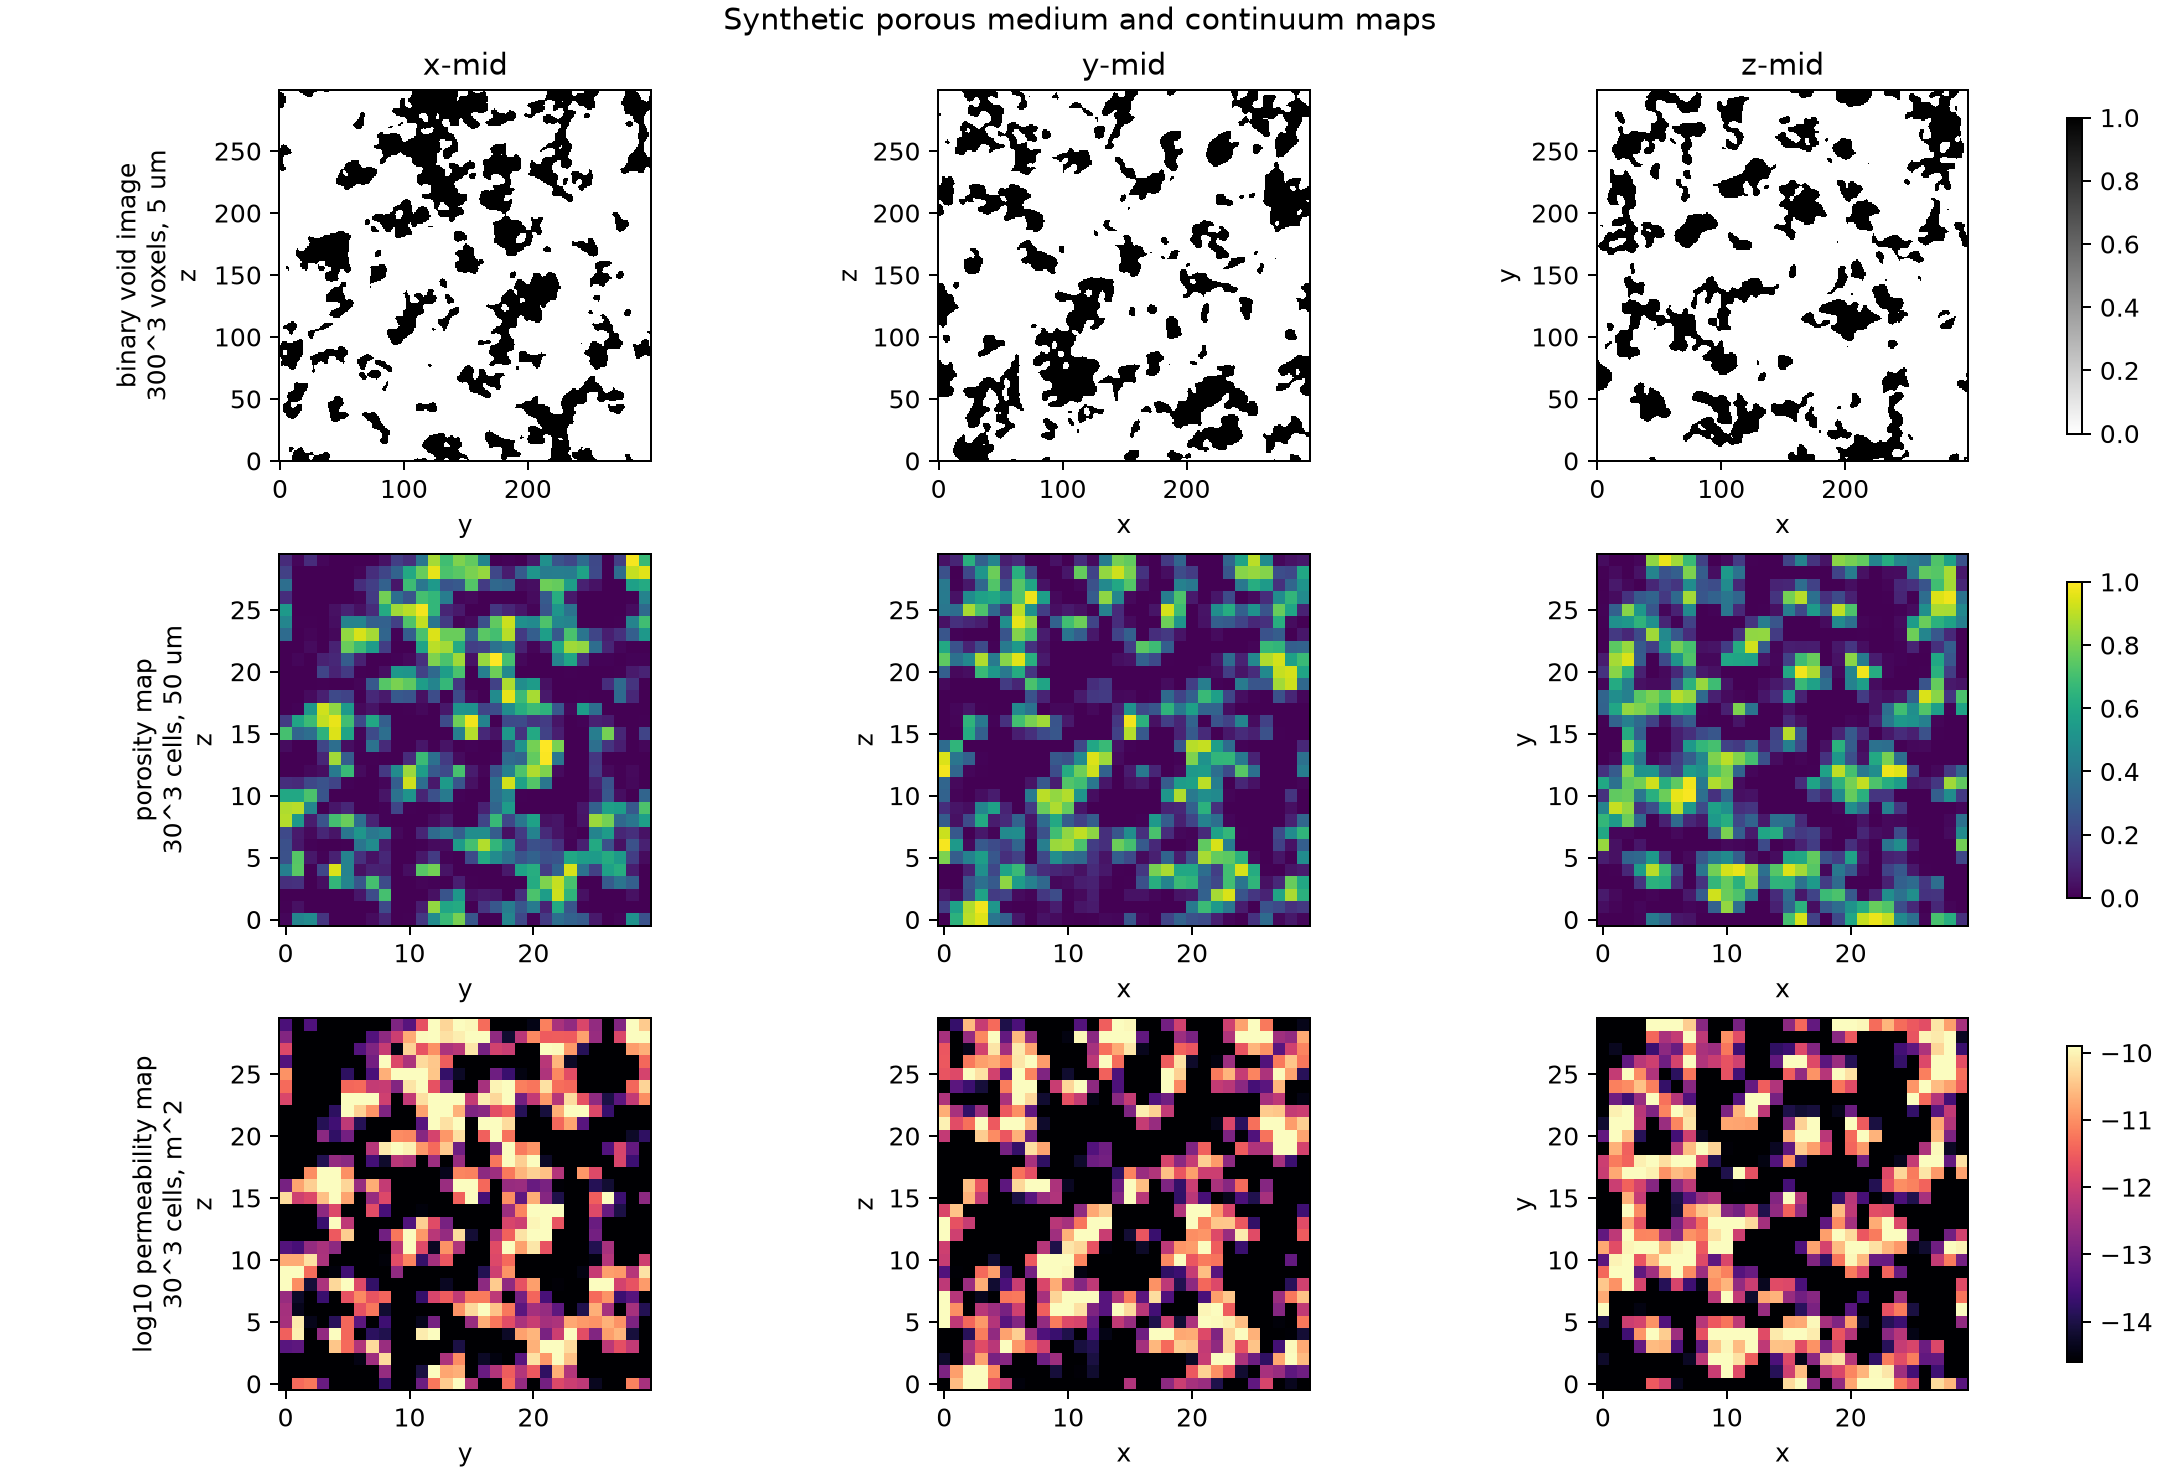

Saved synthetic medium plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_synthetic_medium_mid_slices.png


In [4]:
def plot_synthetic_medium_mid_slices() -> None:
    porosity_values = np.asarray(fem_problem.porosity_map.values, dtype=float)
    permeability_values = np.asarray(tpfa_permeability_map.values, dtype=float)
    log_permeability = np.log10(np.maximum(permeability_values, permeability_floor))
    fine_voxel_label = f"{fine_voxel_size * 1.0e6:.3g} um"
    map_cell_label = f"{cell_size * 1.0e6:.3g} um"
    rows = [
        (
            f"binary void image\n300^3 voxels, {fine_voxel_label}",
            np.asarray(synthetic_void_image, dtype=float),
            "gray_r",
            0.0,
            1.0,
        ),
        (
            f"porosity map\n30^3 cells, {map_cell_label}",
            porosity_values,
            "viridis",
            0.0,
            1.0,
        ),
        (
            "log10 permeability map\n30^3 cells, m^2",
            log_permeability,
            "magma",
            float(np.min(log_permeability)),
            float(np.max(log_permeability)),
        ),
    ]
    fig, axes = plt.subplots(
        len(rows),
        len(midplane_specs),
        figsize=(12.0, 8.2),
        constrained_layout=True,
        squeeze=False,
    )
    for row_index, (row_label, values, cmap, vmin, vmax) in enumerate(rows):
        images = []
        for column_index, (plane_label, plane_axis, in_plane_axes) in enumerate(
            midplane_specs
        ):
            ax = axes[row_index, column_index]
            image = midplane(values, plane_axis).T
            im = ax.imshow(
                image,
                origin="lower",
                cmap=cmap,
                vmin=vmin,
                vmax=vmax,
                interpolation="nearest",
            )
            images.append(im)
            if row_index == 0:
                ax.set_title(plane_label)
            ax.set_xlabel(in_plane_axes[0])
            ax.set_ylabel(
                f"{row_label}\n{in_plane_axes[1]}"
                if column_index == 0
                else in_plane_axes[1]
            )
        fig.colorbar(images[-1], ax=axes[row_index, :].tolist(), shrink=0.85)
    fig.suptitle("Synthetic porous medium and continuum maps")
    figure_path = output_dir / f"{output_prefix}_synthetic_medium_mid_slices.png"
    save_and_display_figure(fig, figure_path)
    print(f"Saved synthetic medium plot: {figure_path}")


plot_synthetic_medium_mid_slices()

In [5]:
print(
    f"Extracting PNM network from original image {image_shape} "
    f"with backend={pnm_extraction_backend!r}...",
    flush=True,
)
pnm_extraction_start = time.perf_counter()
pnm_extraction = extract_spanning_pore_network(
    synthetic_void_image,
    voxel_size=float(fine_voxel_size),
    backend=pnm_extraction_backend,
    flow_axis=flow_axis,
    extraction_kwargs=dict(pnm_extraction_kwargs),
    provenance_notes={
        "notebook": "47_mwe_gpu_solver_backend_comparison",
        "source": "synthetic_void_image",
        "synthetic_image_shape": image_shape,
    },
    geometry_repairs=None,
)
pnm_extraction_seconds = time.perf_counter() - pnm_extraction_start
network = pnm_extraction.net
print(
    f"Extracted spanning PNM network: {network.Np} pores, {network.Nt} throats "
    f"(full: {pnm_extraction.net_full.Np} pores, {pnm_extraction.net_full.Nt} throats) "
    f"in {pnm_extraction_seconds:.3f} s",
    flush=True,
)
fluid = FluidSinglePhase(viscosity=viscosity)
pressure_bc = PressureBC(
    f"inlet_{flow_axis}min",
    f"outlet_{flow_axis}max",
    pin=pressure_inlet,
    pout=pressure_outlet,
)

case_metadata = pd.DataFrame(
    [
        {
            "network_pores": network.Np,
            "network_throats": network.Nt,
            "network_full_pores": pnm_extraction.net_full.Np,
            "network_full_throats": pnm_extraction.net_full.Nt,
            "network_extraction_seconds": pnm_extraction_seconds,
            "network_extraction_backend": pnm_extraction.backend,
            "network_backend_version": pnm_extraction.backend_version,
            "pnm_conductance_model": pnm_conductance_model,
            "image_shape": image_shape,
            "image_voxels": int(np.prod(image_shape)),
            "map_shape": map_shape,
            "map_cells": int(np.prod(map_shape)),
            **synthetic_metadata,
            "flow_axis": flow_axis,
            "pressure_drop": pressure_inlet - pressure_outlet,
            "gpu_device_ids": gpu_device_ids,
            "gpu_dtypes": ", ".join(gpu_dtypes),
            "benchmark_thread_count": benchmark_thread_count,
        }
    ]
)
case_metadata_path = output_dir / f"{output_prefix}_case_metadata.csv"
case_metadata.to_csv(case_metadata_path, index=False)
display(case_metadata)
print(f"Saved case metadata: {case_metadata_path}")

Extracting PNM network from original image (300, 300, 300) with backend='porespy'...


Extracted spanning PNM network: 6653 pores, 11806 throats (full: 7075 pores, 12026 throats) in 76.977 s


,network_pores,network_throats,network_full_pores,network_full_throats,network_extraction_seconds,network_extraction_backend,network_backend_version,pnm_conductance_model,image_shape,image_voxels,...,fine_voxels_per_cell,kozeny_constant,permeability_floor,permeability_cap,porosity_floor,flow_axis,pressure_drop,gpu_device_ids,gpu_dtypes,benchmark_thread_count
0,6653,11806,7075,12026,76.976684,porespy_snow2,3.0.3,auto,"(300, 300, 300)",27000000,...,"(10, 10, 10)",180.0,2.500000e-15,1.250000e-10,0.05,x,1.0,all,"float64, float32",32


Saved case metadata: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_case_metadata.csv


In [6]:
def cudss_parameters(dtype: str) -> dict[str, object]:
    return {"device_ids": gpu_device_ids, "dtype": dtype}


def metadata_value(metadata: dict[str, Any], key: str) -> object:
    return metadata.get(key, "")


def grid_cell_center_points(
    shape: tuple[int, ...],
    cell_size_values: tuple[float, ...],
    origin_values: tuple[float, ...],
) -> np.ndarray:
    axes = [
        origin_values[axis]
        + (np.arange(shape[axis], dtype=float) + 0.5) * cell_size_values[axis]
        for axis in range(len(shape))
    ]
    meshgrid = np.meshgrid(*axes, indexing="ij")
    return np.column_stack([component.reshape(-1, order="C") for component in meshgrid])


field_grid_shape = tuple(int(value) for value in tpfa_permeability_map.shape)
field_grid_cell_size = tuple(float(value) for value in tpfa_permeability_map.cell_size)
field_grid_origin = tuple(float(value) for value in tpfa_permeability_map.origin)
field_grid_points = grid_cell_center_points(
    field_grid_shape,
    field_grid_cell_size,
    field_grid_origin,
)
flow_axis_index = axis_index(flow_axis)
solution_fields: dict[tuple[str, str, str], dict[str, np.ndarray | str]] = {}


def store_solution_field(
    *,
    method_family: str,
    formulation: str,
    backend_label: str,
    pressure: np.ndarray,
    velocity: np.ndarray | None = None,
    note: str = "",
) -> None:
    stored: dict[str, np.ndarray | str] = {
        "pressure": np.asarray(pressure, dtype=float).copy(),
        "note": note,
    }
    if velocity is not None:
        velocity_values = np.asarray(velocity, dtype=float)
        stored["velocity_vector"] = velocity_values.copy()
        stored["velocity_x"] = velocity_values[flow_axis_index].copy()
    solution_fields[(method_family, formulation, backend_label)] = stored


def pnm_pressure_on_common_grid(pore_pressure: np.ndarray) -> np.ndarray:
    tree = cKDTree(np.asarray(network.pore_coords, dtype=float))
    _, nearest = tree.query(field_grid_points)
    return np.asarray(pore_pressure, dtype=float)[nearest].reshape(
        field_grid_shape, order="C"
    )


def capture_pnm_fields(label: str, result: Any) -> str:
    store_solution_field(
        method_family="PNM",
        formulation="pore_network",
        backend_label=label,
        pressure=pnm_pressure_on_common_grid(result.pore_pressure),
        note="nearest-pore projection to the common continuum grid",
    )
    return "ok"


def capture_tpfa_fields(label: str, result: Any) -> str:
    velocity = reconstruct_tpfa_cell_velocity(
        result.pressure,
        tpfa_permeability_map,
        flow_axis=flow_axis,
        viscosity=viscosity,
        pressure_inlet=pressure_inlet,
        pressure_outlet=pressure_outlet,
    )
    store_solution_field(
        method_family="TPFA",
        formulation="tpfa_darcy",
        backend_label=label,
        pressure=result.pressure,
        velocity=velocity,
    )
    return "ok"


def capture_fem_fields(
    formulation: str, label: str, result: FEMSinglePhaseResult
) -> str:
    pressure = sample_dolfinx_function_on_grid(
        result.pressure,
        shape=field_grid_shape,
        cell_size=field_grid_cell_size,
        origin=field_grid_origin,
    )
    velocity = sample_dolfinx_function_on_grid(
        result.velocity,
        shape=field_grid_shape,
        cell_size=field_grid_cell_size,
        origin=field_grid_origin,
    )
    store_solution_field(
        method_family="FEM",
        formulation=formulation,
        backend_label=label,
        pressure=pressure,
        velocity=velocity,
    )
    return "ok"


def capture_field_status(capture: Callable[[], str]) -> str:
    try:
        return capture()
    except Exception as exc:
        return f"{type(exc).__name__}: {exc}"


def run_pnm_case(
    label: str, solver: str, solver_parameters: dict[str, object]
) -> dict[str, object]:
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            result = solve_pnm_singlephase(
                network,
                fluid=fluid,
                bc=pressure_bc,
                axis=flow_axis,
                options=SinglePhaseOptions(
                    conductance_model=pnm_conductance_model,
                    solver=solver,
                    solver_parameters=solver_parameters,
                ),
            )
        except Exception as exc:
            return {
                "method_family": "PNM",
                "formulation": "pore_network",
                "backend_label": label,
                "status": "failed",
                "failure": f"{type(exc).__name__}: {exc}",
                "wall_seconds": time.perf_counter() - start,
                "warning_count": len(caught),
                "warnings": "; ".join(str(item.message) for item in caught),
            }
    solver_info = dict(result.solver_info)
    field_capture = capture_field_status(lambda: capture_pnm_fields(label, result))
    return {
        "method_family": "PNM",
        "formulation": "pore_network",
        "backend_label": label,
        "status": "ok",
        "failure": "",
        "K": float(result.permeability[flow_axis]),
        "flow_rate": float(result.total_flow_rate),
        "solve_seconds": np.nan,
        "wall_seconds": time.perf_counter() - start,
        "residual_relative": float(result.residual_norm),
        "mass_balance_error": float(result.mass_balance_error),
        "solver_method": solver_info.get("method", solver),
        "solver_backend": solver_info.get("backend", ""),
        "cudss_dtype": solver_info.get("serial_sparse_nvmath_cudss_dtype", ""),
        "cudss_residual": solver_info.get(
            "serial_sparse_nvmath_cudss_relative_residual", ""
        ),
        "cudss_backend_seconds": solver_info.get(
            "serial_sparse_nvmath_cudss_backend_seconds", ""
        ),
        "cudss_device_names": solver_info.get(
            "serial_sparse_nvmath_cudss_device_names", ""
        ),
        "metadata_json": json.dumps(solver_info, sort_keys=True, default=str),
        "field_capture": field_capture,
        "warning_count": len(caught),
        "warnings": "; ".join(str(item.message) for item in caught),
    }


def run_tpfa_case(
    label: str,
    solver_method: str,
    solver_parameters: dict[str, object],
) -> dict[str, object]:
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            result = solve_tpfa(
                tpfa_permeability_map,
                flow_axis=flow_axis,
                viscosity=viscosity,
                pressure_inlet=pressure_inlet,
                pressure_outlet=pressure_outlet,
                solver_method=solver_method,
                solver_parameters=solver_parameters,
            )
        except Exception as exc:
            return {
                "method_family": "TPFA",
                "formulation": "tpfa_darcy",
                "backend_label": label,
                "status": "failed",
                "failure": f"{type(exc).__name__}: {exc}",
                "wall_seconds": time.perf_counter() - start,
                "warning_count": len(caught),
                "warnings": "; ".join(str(item.message) for item in caught),
            }
    solver_info = dict(result.solver_info)
    field_capture = capture_field_status(lambda: capture_tpfa_fields(label, result))
    return {
        "method_family": "TPFA",
        "formulation": "tpfa_darcy",
        "backend_label": label,
        "status": "ok",
        "failure": "",
        "K": float(result.permeability),
        "flow_rate": float(result.flow_rate),
        "solve_seconds": float(result.solve_seconds),
        "wall_seconds": time.perf_counter() - start,
        "residual_relative": float(result.residual_relative),
        "mass_balance_error": float(result.mass_balance_error),
        "matrix_nnz": int(result.matrix_nnz),
        "solver_method": result.solver_method,
        "solver_backend": solver_info.get("backend", ""),
        "cudss_dtype": solver_info.get("serial_sparse_nvmath_cudss_dtype", ""),
        "cudss_residual": solver_info.get(
            "serial_sparse_nvmath_cudss_relative_residual", ""
        ),
        "cudss_backend_seconds": solver_info.get(
            "serial_sparse_nvmath_cudss_backend_seconds", ""
        ),
        "cudss_device_names": solver_info.get(
            "serial_sparse_nvmath_cudss_device_names", ""
        ),
        "metadata_json": json.dumps(solver_info, sort_keys=True, default=str),
        "field_capture": field_capture,
        "warning_count": len(caught),
        "warnings": "; ".join(str(item.message) for item in caught),
    }


FEMSolver = Callable[..., FEMSinglePhaseResult]


def run_fem_case(
    *,
    formulation: str,
    solver: FEMSolver,
    label: str,
    options: FEniCSSolverOptions,
) -> dict[str, object]:
    start = time.perf_counter()
    with warnings.catch_warnings(record=True) as caught:
        warnings.simplefilter("always")
        try:
            solver_kwargs: dict[str, object] = {
                "flow_axis": flow_axis,
                "pressure_inlet": pressure_inlet,
                "pressure_outlet": pressure_outlet,
                "options": options,
            }
            if "brinkman" in formulation:
                solver_kwargs["nondimensional"] = True
            result = solver(fem_problem, **solver_kwargs)
        except Exception as exc:
            return {
                "method_family": "FEM",
                "formulation": formulation,
                "backend_label": label,
                "status": "failed",
                "failure": f"{type(exc).__name__}: {exc}",
                "wall_seconds": time.perf_counter() - start,
                "warning_count": len(caught),
                "warnings": "; ".join(str(item.message) for item in caught),
            }
    metadata = dict(result.metadata)
    field_capture = capture_field_status(
        lambda: capture_fem_fields(formulation, label, result)
    )
    return {
        "method_family": "FEM",
        "formulation": formulation,
        "backend_label": label,
        "status": "ok",
        "failure": "",
        "K": float(result.permeability),
        "flow_rate": float(result.flow_rate),
        "solve_seconds": float(result.solve_seconds),
        "wall_seconds": time.perf_counter() - start,
        "residual_relative": metadata_value(
            metadata, "serial_sparse_nvmath_cudss_relative_residual"
        ),
        "mass_balance_error": np.nan,
        "matrix_nnz": metadata_value(metadata, "serial_sparse_matrix_nnz"),
        "solver_method": metadata.get("linear_backend", ""),
        "solver_backend": metadata.get("serial_sparse_solver_backend", ""),
        "cudss_dtype": metadata.get("serial_sparse_nvmath_cudss_dtype", ""),
        "cudss_residual": metadata.get(
            "serial_sparse_nvmath_cudss_relative_residual", ""
        ),
        "cudss_backend_seconds": metadata.get(
            "serial_sparse_nvmath_cudss_backend_seconds", ""
        ),
        "cudss_device_names": metadata.get(
            "serial_sparse_nvmath_cudss_device_names", ""
        ),
        "metadata_json": json.dumps(metadata, sort_keys=True, default=str),
        "field_capture": field_capture,
        "warning_count": len(caught),
        "warnings": "; ".join(str(item.message) for item in caught),
    }

In [7]:
backend_rows: list[dict[str, object]] = [
    {
        "method_family": "PNM",
        "formulation": "pore_network",
        "backend_label": "direct_cpu_reference",
        "solver": "direct",
        "solver_parameters": {},
    },
    {
        "method_family": "PNM",
        "formulation": "pore_network",
        "backend_label": "pardiso_cpu_reference",
        "solver": "pardiso",
        "solver_parameters": {},
    },
    {
        "method_family": "TPFA",
        "formulation": "tpfa_darcy",
        "backend_label": "direct_cpu_reference",
        "solver": "direct",
        "solver_parameters": {},
    },
    {
        "method_family": "TPFA",
        "formulation": "tpfa_darcy",
        "backend_label": "pardiso_cpu_reference",
        "solver": "pardiso",
        "solver_parameters": {},
    },
]
for dtype in gpu_dtypes:
    backend_rows.extend(
        [
            {
                "method_family": "PNM",
                "formulation": "pore_network",
                "backend_label": f"nvmath_cudss_{dtype}",
                "solver": "nvmath_cudss",
                "solver_parameters": cudss_parameters(dtype),
            },
            {
                "method_family": "TPFA",
                "formulation": "tpfa_darcy",
                "backend_label": f"nvmath_cudss_{dtype}",
                "solver": "nvmath_cudss",
                "solver_parameters": cudss_parameters(dtype),
            },
        ]
    )

fem_formulations: list[dict[str, object]] = [
    {
        "formulation": "darcy_taylor_hood_p2p1",
        "solver": solve_darcy_taylor_hood,
        "reference_label": "pardiso_cpu_reference",
        "reference_options": FEniCSSolverOptions.pardiso_direct(),
    },
    {
        "formulation": "brinkman_taylor_hood_p2p1",
        "solver": solve_brinkman_taylor_hood,
        "reference_label": "pardiso_cpu_reference",
        "reference_options": FEniCSSolverOptions.pardiso_direct(),
    },
    {
        "formulation": "brinkman_usfem_p1dg1",
        "solver": solve_brinkman_usfem,
        "reference_label": "superlu_dist_cpu_reference",
        "reference_options": FEniCSSolverOptions.direct_parallel("superlu_dist"),
    },
]
fem_gpu_backends: list[dict[str, object]] = []
for dtype in gpu_dtypes:
    fem_gpu_backends.append(
        {
            "backend_label": f"nvmath_cudss_{dtype}",
            "options": FEniCSSolverOptions.nvmath_cudss_direct(
                device_ids=gpu_device_ids,
                dtype=dtype,  # type: ignore[arg-type]
            ),
        }
    )

display(pd.DataFrame(backend_rows))
display(
    pd.DataFrame(
        [
            {
                "formulation": item["formulation"],
                "backend_label": item["reference_label"],
                "linear_backend": item["reference_options"].linear_backend,
                "role": "cpu_reference",
            }
            for item in fem_formulations
        ]
        + [
            {
                "formulation": item["formulation"],
                "backend_label": backend["backend_label"],
                "linear_backend": backend["options"].linear_backend,
                "role": "gpu_candidate",
            }
            for item in fem_formulations
            for backend in fem_gpu_backends
        ]
    )
)

,method_family,formulation,backend_label,solver,solver_parameters
0,PNM,pore_network,direct_cpu_reference,direct,{}
1,PNM,pore_network,pardiso_cpu_reference,pardiso,{}
2,TPFA,tpfa_darcy,direct_cpu_reference,direct,{}
3,TPFA,tpfa_darcy,pardiso_cpu_reference,pardiso,{}
4,PNM,pore_network,nvmath_cudss_float64,nvmath_cudss,"{'device_ids': 'all', 'dtype': 'float64'}"
5,TPFA,tpfa_darcy,nvmath_cudss_float64,nvmath_cudss,"{'device_ids': 'all', 'dtype': 'float64'}"
6,PNM,pore_network,nvmath_cudss_float32,nvmath_cudss,"{'device_ids': 'all', 'dtype': 'float32'}"
7,TPFA,tpfa_darcy,nvmath_cudss_float32,nvmath_cudss,"{'device_ids': 'all', 'dtype': 'float32'}"


,formulation,backend_label,linear_backend,role
0,darcy_taylor_hood_p2p1,pardiso_cpu_reference,pardiso,cpu_reference
1,brinkman_taylor_hood_p2p1,pardiso_cpu_reference,pardiso,cpu_reference
2,brinkman_usfem_p1dg1,superlu_dist_cpu_reference,petsc,cpu_reference
3,darcy_taylor_hood_p2p1,nvmath_cudss_float64,nvmath_cudss,gpu_candidate
4,darcy_taylor_hood_p2p1,nvmath_cudss_float32,nvmath_cudss,gpu_candidate
5,brinkman_taylor_hood_p2p1,nvmath_cudss_float64,nvmath_cudss,gpu_candidate
6,brinkman_taylor_hood_p2p1,nvmath_cudss_float32,nvmath_cudss,gpu_candidate
7,brinkman_usfem_p1dg1,nvmath_cudss_float64,nvmath_cudss,gpu_candidate
8,brinkman_usfem_p1dg1,nvmath_cudss_float32,nvmath_cudss,gpu_candidate


In [8]:
rows: list[dict[str, object]] = []
results_path = output_dir / f"{output_prefix}_results.csv"
if run_benchmark:
    for spec in backend_rows:
        print(
            f"Running row: {spec['method_family']} | {spec['formulation']} | "
            f"{spec['backend_label']}",
            flush=True,
        )
        if spec["method_family"] == "PNM":
            row = run_pnm_case(
                str(spec["backend_label"]),
                str(spec["solver"]),
                dict(spec["solver_parameters"]),
            )
        elif spec["method_family"] == "TPFA":
            row = run_tpfa_case(
                str(spec["backend_label"]),
                str(spec["solver"]),
                dict(spec["solver_parameters"]),
            )
        else:
            raise ValueError(f"Unknown method family {spec['method_family']!r}")
        rows.append(row)
        pd.DataFrame(rows).to_csv(results_path, index=False)
        print(
            f"Saved row: {row['method_family']} | {row['formulation']} | "
            f"{row['backend_label']} | {row['status']}",
            flush=True,
        )

    for formulation in fem_formulations:
        fem_backend_rows = [
            {
                "backend_label": formulation["reference_label"],
                "options": formulation["reference_options"],
            },
            *fem_gpu_backends,
        ]
        for backend in fem_backend_rows:
            print(
                f"Running row: FEM | {formulation['formulation']} | {backend['backend_label']}",
                flush=True,
            )
            row = run_fem_case(
                formulation=str(formulation["formulation"]),
                solver=formulation["solver"],  # type: ignore[arg-type]
                label=str(backend["backend_label"]),
                options=backend["options"],  # type: ignore[arg-type]
            )
            rows.append(row)
            pd.DataFrame(rows).to_csv(results_path, index=False)
            print(
                f"Saved row: {row['method_family']} | {row['formulation']} | "
                f"{row['backend_label']} | {row['status']}",
                flush=True,
            )

results = pd.DataFrame(rows)

reference_rows = (
    results[
        (results["status"] == "ok")
        & results["backend_label"].str.endswith("_cpu_reference")
    ]
    .sort_values(["method_family", "formulation", "wall_seconds"])
    .drop_duplicates(["method_family", "formulation"], keep="first")
    if not results.empty
    else pd.DataFrame()
)
reference_by_formulation = (
    reference_rows.set_index(["method_family", "formulation"])["K"].to_dict()
    if not reference_rows.empty
    else {}
)
reference_label_by_formulation = (
    reference_rows.set_index(["method_family", "formulation"])[
        "backend_label"
    ].to_dict()
    if not reference_rows.empty
    else {}
)
if not results.empty:
    results["K_reference"] = [
        reference_by_formulation.get((row.method_family, row.formulation), np.nan)
        for row in results.itertuples(index=False)
    ]
    results["K_reference_backend"] = [
        reference_label_by_formulation.get((row.method_family, row.formulation), "")
        for row in results.itertuples(index=False)
    ]
    results["K_relative_to_reference"] = np.where(
        (results["status"] == "ok") & np.isfinite(results["K_reference"]),
        np.abs(results["K"] - results["K_reference"])
        / np.maximum(np.abs(results["K_reference"]), 1.0e-300),
        np.nan,
    )

results.to_csv(results_path, index=False)
display(results)
print(f"Saved benchmark rows: {results_path}")

Running row: PNM | pore_network | direct_cpu_reference


Saved row: PNM | pore_network | direct_cpu_reference | ok


Running row: PNM | pore_network | pardiso_cpu_reference


Saved row: PNM | pore_network | pardiso_cpu_reference | ok


Running row: TPFA | tpfa_darcy | direct_cpu_reference


...

Saved row: FEM | brinkman_usfem_p1dg1 | nvmath_cudss_float64 | ok


Running row: FEM | brinkman_usfem_p1dg1 | nvmath_cudss_float32


Saved row: FEM | brinkman_usfem_p1dg1 | nvmath_cudss_float32 | ok


,method_family,formulation,backend_label,status,failure,K,flow_rate,solve_seconds,wall_seconds,residual_relative,...,cudss_backend_seconds,cudss_device_names,metadata_json,field_capture,warning_count,warnings,matrix_nnz,K_reference,K_reference_backend,K_relative_to_reference
0,PNM,pore_network,direct_cpu_reference,ok,,8.789510e-13,1.318427e-15,NaN,1.347682,0.0,...,,,"{""backend"": ""scipy.sparse.linalg.spsolve"", ""in...",ok,0,,NaN,8.789510e-13,pardiso_cpu_reference,4.089740e-14
1,PNM,pore_network,pardiso_cpu_reference,ok,,8.789510e-13,1.318427e-15,NaN,1.065739,0.0,...,,,"{""backend"": ""pypardiso"", ""info"": 0, ""method"": ...",ok,0,,NaN,8.789510e-13,pardiso_cpu_reference,0.000000e+00
2,TPFA,tpfa_darcy,direct_cpu_reference,ok,,8.343776e-13,1.251566e-15,0.891690,0.922865,0.0,...,,,"{""backend"": ""scipy.sparse.linalg.spsolve"", ""in...",ok,0,,183600,8.343776e-13,pardiso_cpu_reference,1.253740e-13
3,TPFA,tpfa_darcy,pardiso_cpu_reference,ok,,8.343776e-13,1.251566e-15,0.164791,0.179922,0.0,...,,,"{""backend"": ""pypardiso"", ""info"": 0, ""method"": ...",ok,0,,183600,8.343776e-13,pardiso_cpu_reference,0.000000e+00
4,PNM,pore_network,nvmath_cudss_float64,ok,,8.789510e-13,1.318427e-15,NaN,2.391051,0.0,...,0.119498,"(NVIDIA RTX A5000, NVIDIA RTX A5000)","{""backend"": ""nvmath.bindings.cudss"", ""info"": 0...",ok,0,,NaN,8.789510e-13,pardiso_cpu_reference,2.527368e-15
5,TPFA,tpfa_darcy,nvmath_cudss_float64,ok,,8.343776e-13,1.251566e-15,0.461091,0.491788,0.0,...,0.456028,"(NVIDIA RTX A5000, NVIDIA RTX A5000)","{""backend"": ""nvmath.bindings.cudss"", ""info"": 0...",ok,0,,183600,8.343776e-13,pardiso_cpu_reference,6.534939e-15
6,PNM,pore_network,nvmath_cudss_float32,ok,,8.789617e-13,1.318443e-15,NaN,1.290600,0.0,...,0.061644,"(NVIDIA RTX A5000, NVIDIA RTX A5000)","{""backend"": ""nvmath.bindings.cudss"", ""info"": 0...",ok,0,,NaN,8.789510e-13,pardiso_cpu_reference,1.211282e-05
7,TPFA,tpfa_darcy,nvmath_cudss_float32,ok,,8.343361e-13,1.251504e-15,0.340061,0.354435,0.0,...,0.335307,"(NVIDIA RTX A5000, NVIDIA RTX A5000)","{""backend"": ""nvmath.bindings.cudss"", ""info"": 0...",ok,0,,183600,8.343776e-13,pardiso_cpu_reference,4.977393e-05
8,FEM,darcy_taylor_hood_p2p1,pardiso_cpu_reference,ok,,1.369678e-12,2.054517e-15,122.936485,133.947787,,...,,,"{""linear_backend"": ""pardiso"", ""mpi_rank"": 0, ""...",ok,0,,68278966,1.369678e-12,pardiso_cpu_reference,0.000000e+00
9,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float64,ok,,1.369678e-12,2.054517e-15,88.258574,97.749239,0.0,...,74.178515,"(NVIDIA RTX A5000, NVIDIA RTX A5000)","{""linear_backend"": ""nvmath_cudss"", ""mpi_rank"":...",ok,0,,68278966,1.369678e-12,pardiso_cpu_reference,0.000000e+00


Saved benchmark rows: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_results.csv


In [9]:
ok = results[results["status"] == "ok"].copy() if not results.empty else pd.DataFrame()
failures = (
    results[results["status"] != "ok"].copy()
    if not results.empty
    else pd.DataFrame(
        columns=["method_family", "formulation", "backend_label", "failure"]
    )
)
display(failures)

summary = (
    ok.groupby(["method_family", "formulation", "backend_label"], dropna=False)
    .agg(
        K=("K", "first"),
        K_reference=("K_reference", "first"),
        K_reference_backend=("K_reference_backend", "first"),
        K_relative_to_reference=("K_relative_to_reference", "first"),
        solve_seconds=("solve_seconds", "first"),
        wall_seconds=("wall_seconds", "first"),
        cudss_backend_seconds=("cudss_backend_seconds", "first"),
        cudss_residual=("cudss_residual", "first"),
        matrix_nnz=("matrix_nnz", "first"),
        solver_backend=("solver_backend", "first"),
    )
    .reset_index()
    if not ok.empty
    else pd.DataFrame()
)
summary_path = output_dir / f"{output_prefix}_summary.csv"
summary.to_csv(summary_path, index=False)
display(summary)
print(f"Saved summary: {summary_path}")

,method_family,formulation,backend_label,status,failure,K,flow_rate,solve_seconds,wall_seconds,residual_relative,...,cudss_backend_seconds,cudss_device_names,metadata_json,field_capture,warning_count,warnings,matrix_nnz,K_reference,K_reference_backend,K_relative_to_reference
13,FEM,brinkman_taylor_hood_p2p1,nvmath_cudss_float32,failed,RuntimeError: nvmath_cudss residual check fail...,NaN,NaN,NaN,45.849038,NaN,...,NaN,NaN,NaN,NaN,0,,NaN,9.805723e-13,pardiso_cpu_reference,NaN


,method_family,formulation,backend_label,K,K_reference,K_reference_backend,K_relative_to_reference,solve_seconds,wall_seconds,cudss_backend_seconds,cudss_residual,matrix_nnz,solver_backend
0,FEM,brinkman_taylor_hood_p2p1,nvmath_cudss_float64,9.805723e-13,9.805723e-13,pardiso_cpu_reference,0.000000e+00,94.998007,105.499083,75.548264,0.0,68278966,nvmath.bindings.cudss
1,FEM,brinkman_taylor_hood_p2p1,pardiso_cpu_reference,9.805723e-13,9.805723e-13,pardiso_cpu_reference,0.000000e+00,119.927875,128.983978,,,68278966,pypardiso.spsolve
2,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float32,2.543817e-13,2.543846e-13,superlu_dist_cpu_reference,1.118527e-05,45.033188,48.343014,23.073898,0.000001,50365539,nvmath.bindings.cudss
3,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float64,2.543846e-13,2.543846e-13,superlu_dist_cpu_reference,6.938428e-13,99.032250,102.379988,77.079307,0.0,50365539,nvmath.bindings.cudss
4,FEM,brinkman_usfem_p1dg1,superlu_dist_cpu_reference,2.543846e-13,2.543846e-13,superlu_dist_cpu_reference,0.000000e+00,134.295313,138.369116,,,,
5,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float32,1.369678e-12,1.369678e-12,pardiso_cpu_reference,3.152611e-08,39.324017,48.106650,25.406927,0.0,68278966,nvmath.bindings.cudss
6,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float64,1.369678e-12,1.369678e-12,pardiso_cpu_reference,0.000000e+00,88.258574,97.749239,74.178515,0.0,68278966,nvmath.bindings.cudss
7,FEM,darcy_taylor_hood_p2p1,pardiso_cpu_reference,1.369678e-12,1.369678e-12,pardiso_cpu_reference,0.000000e+00,122.936485,133.947787,,,68278966,pypardiso.spsolve
8,PNM,pore_network,direct_cpu_reference,8.789510e-13,8.789510e-13,pardiso_cpu_reference,4.089740e-14,NaN,1.347682,,,None,scipy.sparse.linalg.spsolve
9,PNM,pore_network,nvmath_cudss_float32,8.789617e-13,8.789510e-13,pardiso_cpu_reference,1.211282e-05,NaN,1.290600,0.061644,0.0,None,nvmath.bindings.cudss


Saved summary: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_summary.csv


## Plots

The plots compare successful rows only. Failed rows remain in the tables and
CSVs so missing optional runtimes or unsupported configurations are visible.

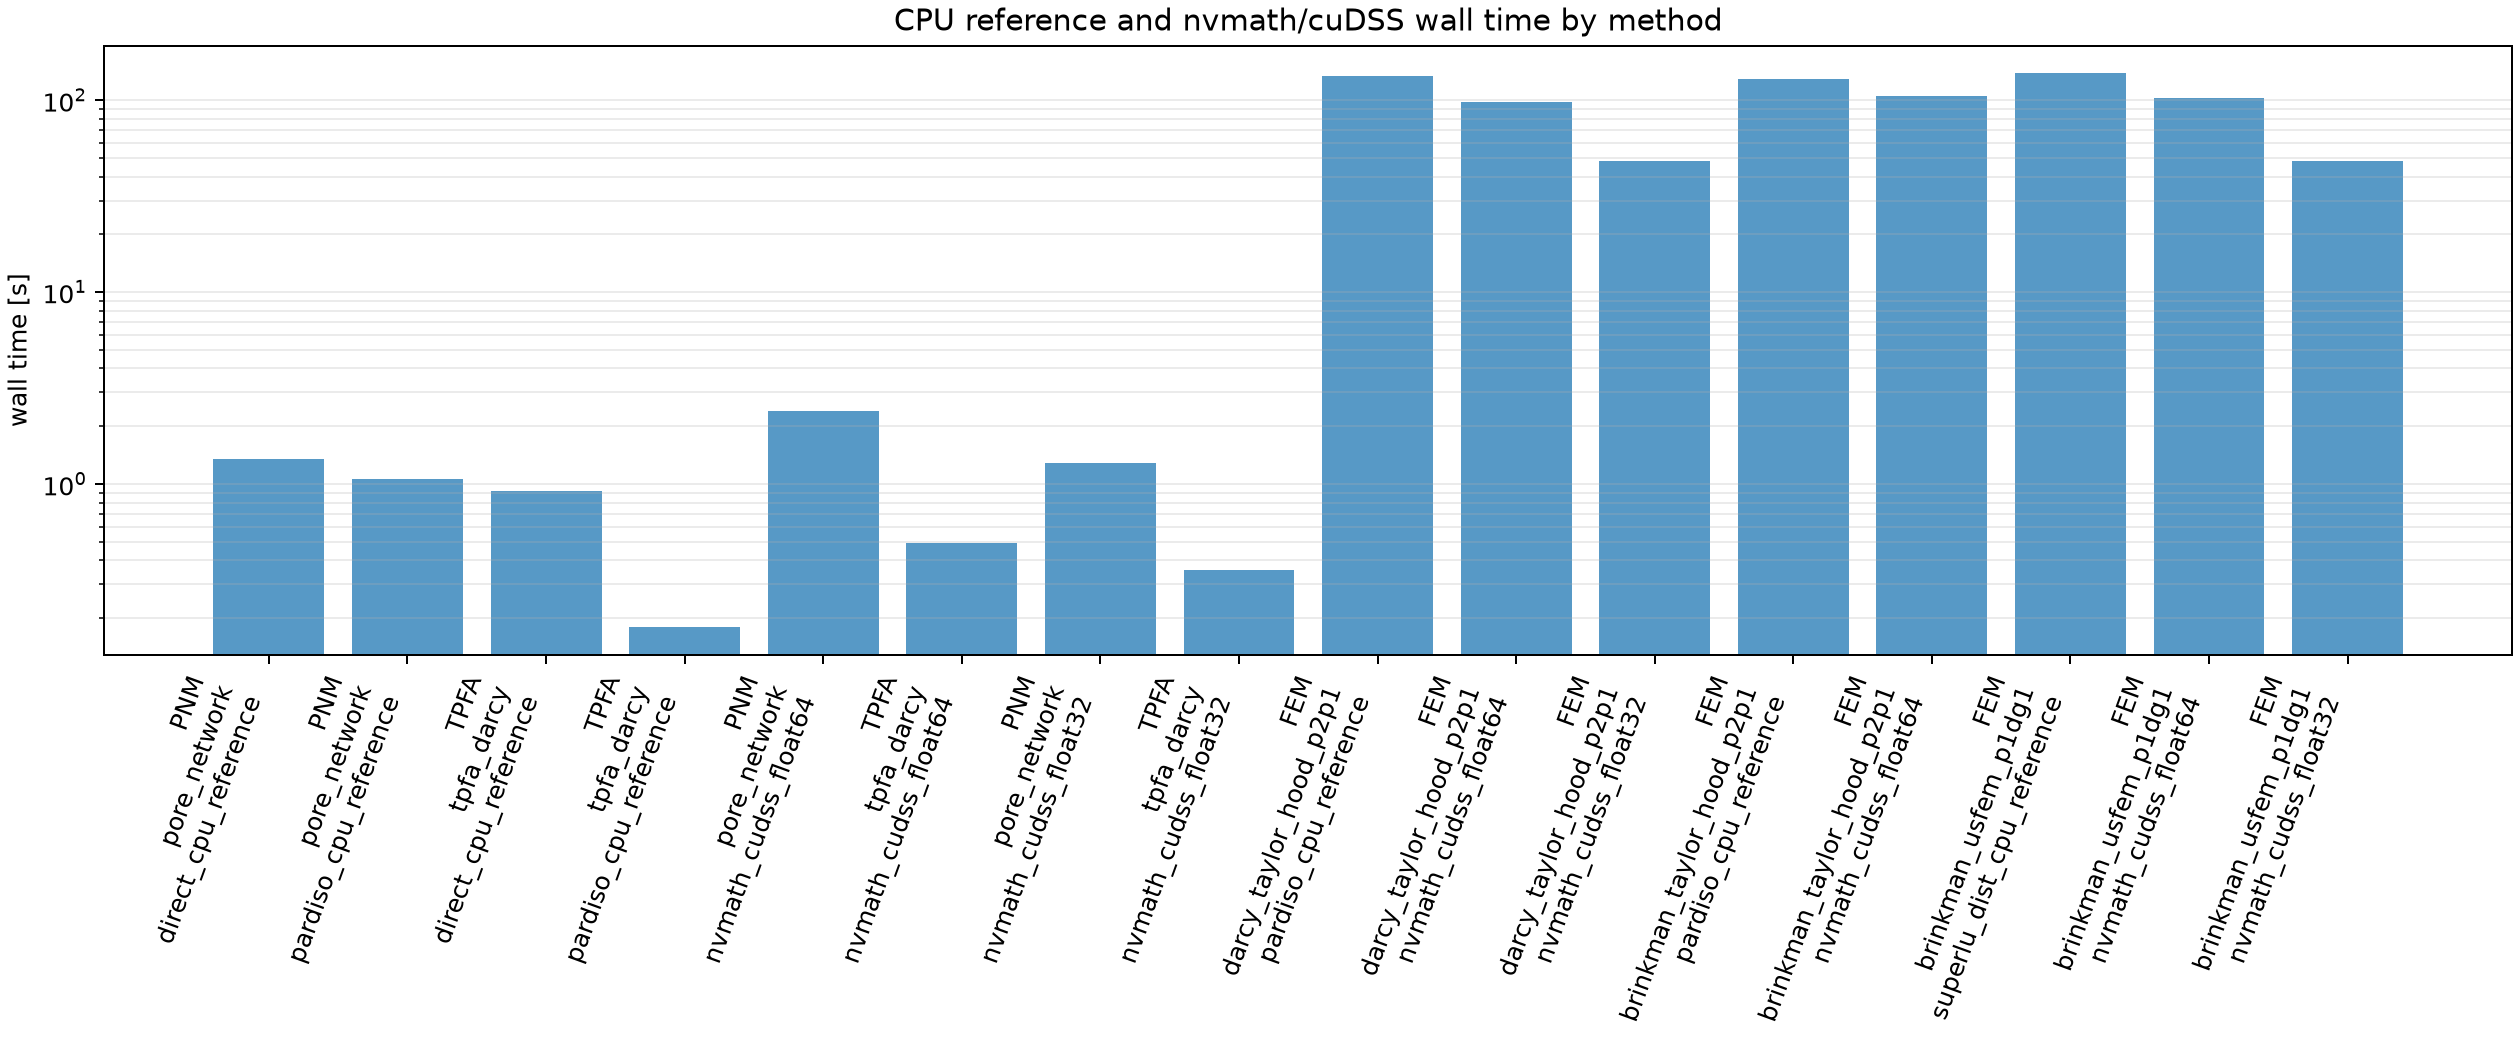

Saved wall-time plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_wall_time.png


In [10]:
if ok.empty:
    print("No successful rows to plot.")
else:
    plot_df = ok.copy()
    plot_df["label"] = (
        plot_df["method_family"].astype(str)
        + "\n"
        + plot_df["formulation"].astype(str)
        + "\n"
        + plot_df["backend_label"].astype(str)
    )
    x = np.arange(len(plot_df), dtype=float)
    fig, ax = plt.subplots(figsize=(14.0, 5.8), constrained_layout=True)
    ax.bar(x, plot_df["wall_seconds"], color="tab:blue", alpha=0.75)
    ax.set_yscale("log")
    ax.set_ylabel("wall time [s]")
    ax.set_title("CPU reference and nvmath/cuDSS wall time by method")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_df["label"], rotation=70, ha="right")
    ax.grid(axis="y", which="both", alpha=0.25)
    timing_plot_path = output_dir / f"{output_prefix}_wall_time.png"
    save_and_display_figure(fig, timing_plot_path)
    print(f"Saved wall-time plot: {timing_plot_path}")

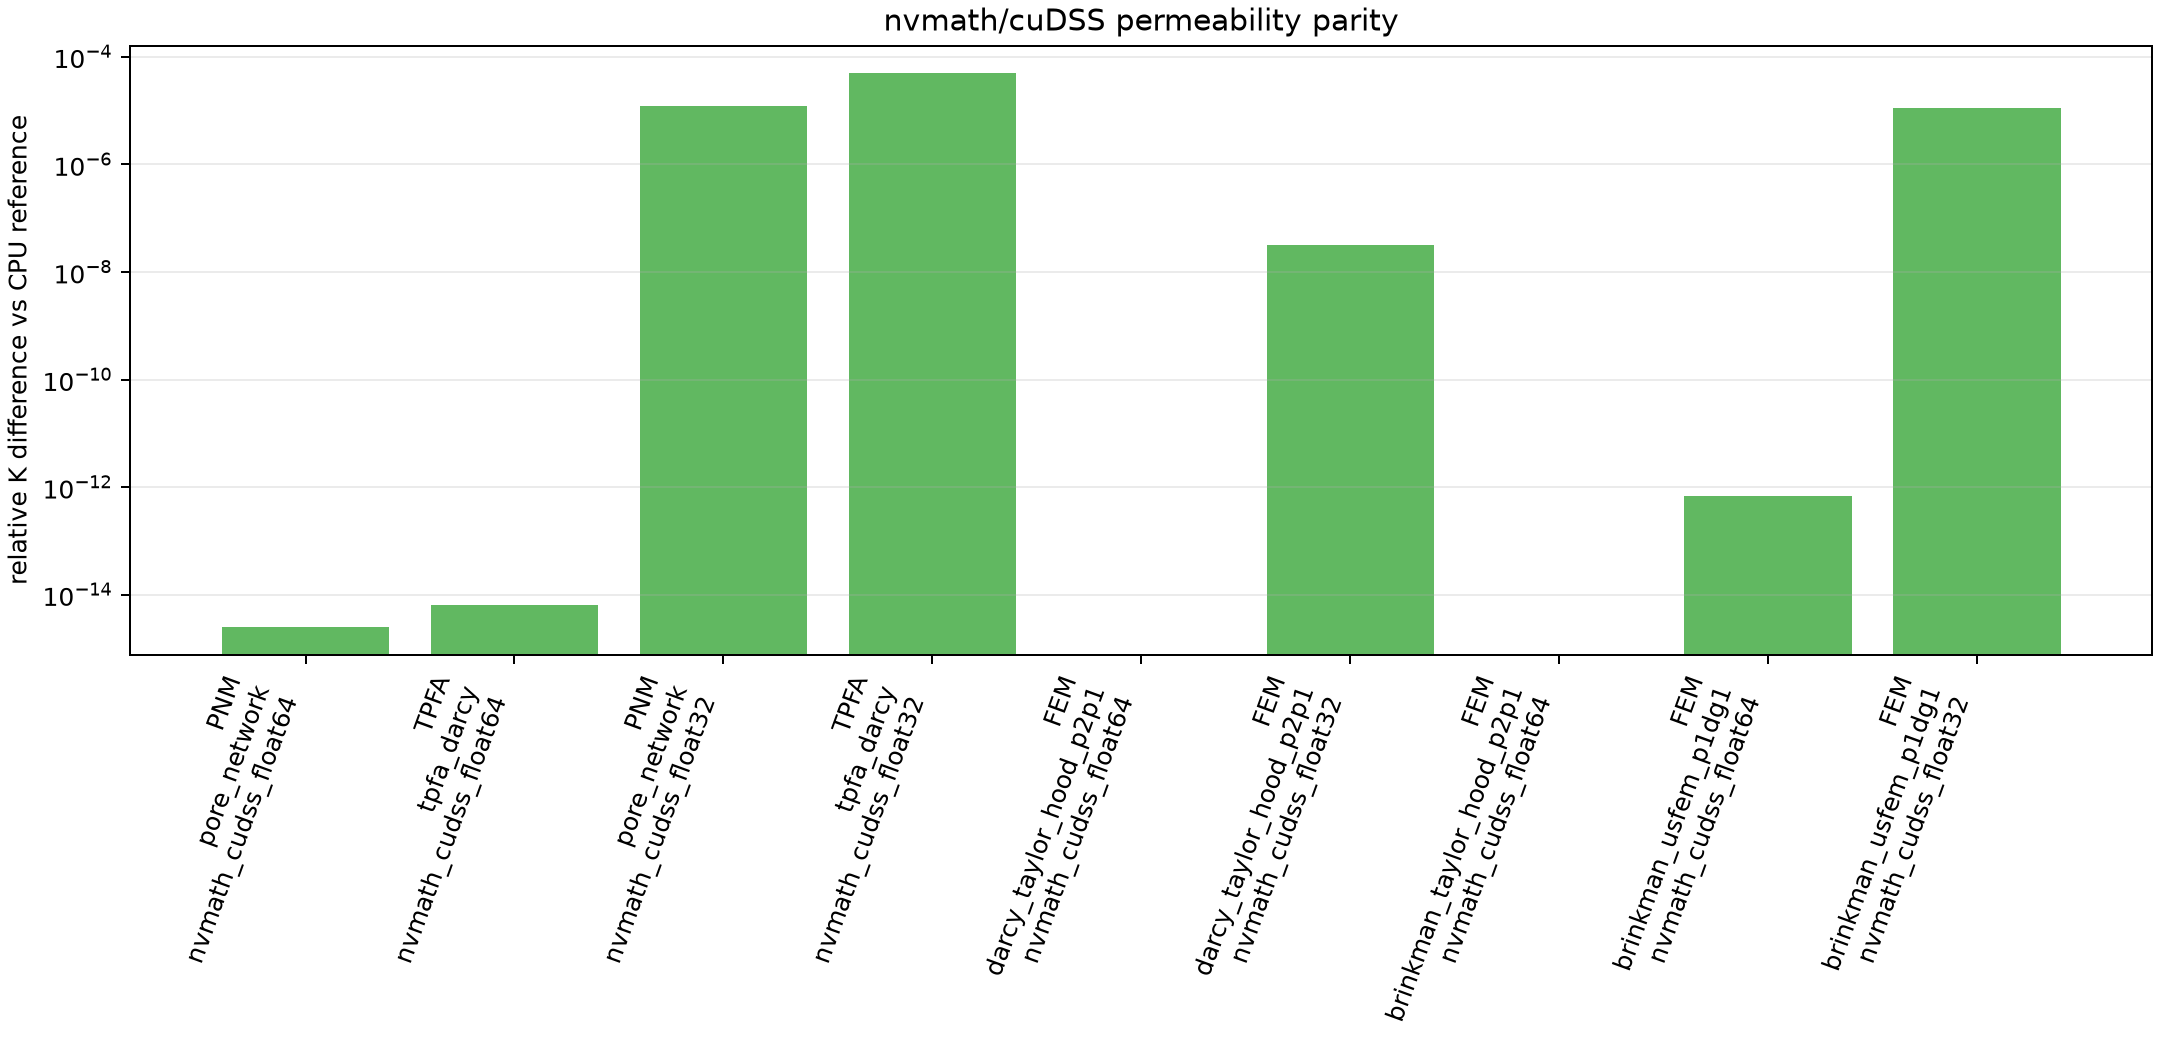

Saved K parity plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_k_relative_error.png


In [11]:
accuracy_df = (
    ok[ok["K_relative_to_reference"].notna()].copy() if not ok.empty else pd.DataFrame()
)
accuracy_df = accuracy_df[~accuracy_df["backend_label"].str.endswith("_cpu_reference")]
if accuracy_df.empty:
    print("No cuDSS rows with CPU references to plot.")
else:
    accuracy_df["label"] = (
        accuracy_df["method_family"].astype(str)
        + "\n"
        + accuracy_df["formulation"].astype(str)
        + "\n"
        + accuracy_df["backend_label"].astype(str)
    )
    x = np.arange(len(accuracy_df), dtype=float)
    fig, ax = plt.subplots(figsize=(12.0, 5.8), constrained_layout=True)
    ax.bar(x, accuracy_df["K_relative_to_reference"], color="tab:green", alpha=0.75)
    ax.set_yscale("log")
    ax.set_ylabel("relative K difference vs CPU reference")
    ax.set_title("nvmath/cuDSS permeability parity")
    ax.set_xticks(x)
    ax.set_xticklabels(accuracy_df["label"], rotation=70, ha="right")
    ax.grid(axis="y", which="both", alpha=0.25)
    accuracy_plot_path = output_dir / f"{output_prefix}_k_relative_error.png"
    save_and_display_figure(fig, accuracy_plot_path)
    print(f"Saved K parity plot: {accuracy_plot_path}")

## Field Comparisons

Successful rows are also sampled onto the common 30³ cell-centered grid. TPFA
pressure already lives on that grid, FEM pressure and velocity are sampled at
cell centers, and PNM pore pressures are projected to the grid by nearest pore.
Each comparison plot shows the CPU reference, cuDSS float64, cuDSS float32,
the absolute float32 error, and the signed float32-reference difference.

,field,field_vmin,field_vmax,abs_error_vmin,abs_error_vmax,signed_diff_vmin,signed_diff_vmax
0,pressure,-6.422312e-01,1.000007e+00,0.0,1.043293e-04,-1.043293e-04,1.043293e-04
1,velocity_x,-3.150439e-08,3.440367e-07,0.0,4.245906e-12,-4.245906e-12,4.245906e-12


Saved field color scales: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_color_scales.csv


,method_family,formulation,backend_label,field,reference_backend,relative_l2,relative_linf,absolute_linf
0,FEM,brinkman_taylor_hood_p2p1,nvmath_cudss_float64,pressure,pardiso_cpu_reference,4.712509e-16,1.736922e-15,1.054712e-15
1,FEM,brinkman_taylor_hood_p2p1,nvmath_cudss_float64,velocity_x,pardiso_cpu_reference,1.161859e-14,6.919740e-15,1.071199e-21
2,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float64,pressure,superlu_dist_cpu_reference,4.425995e-13,1.379327e-12,8.858470e-13
3,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float64,velocity_x,superlu_dist_cpu_reference,9.881202e-13,1.610723e-12,1.547159e-20
4,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float32,pressure,superlu_dist_cpu_reference,3.768741e-05,1.624483e-04,1.043293e-04
5,FEM,brinkman_usfem_p1dg1,nvmath_cudss_float32,velocity_x,superlu_dist_cpu_reference,9.465635e-05,2.328340e-04,2.236455e-12
6,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float64,pressure,pardiso_cpu_reference,4.054033e-16,1.469853e-15,8.881784e-16
7,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float64,velocity_x,pardiso_cpu_reference,2.360556e-14,1.640120e-14,5.642613e-21
8,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float32,pressure,pardiso_cpu_reference,1.357916e-07,5.997113e-07,3.623837e-07
9,FEM,darcy_taylor_hood_p2p1,nvmath_cudss_float32,velocity_x,pardiso_cpu_reference,9.672211e-06,5.391857e-06,1.854996e-12


Saved field error metrics: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_error_metrics.csv


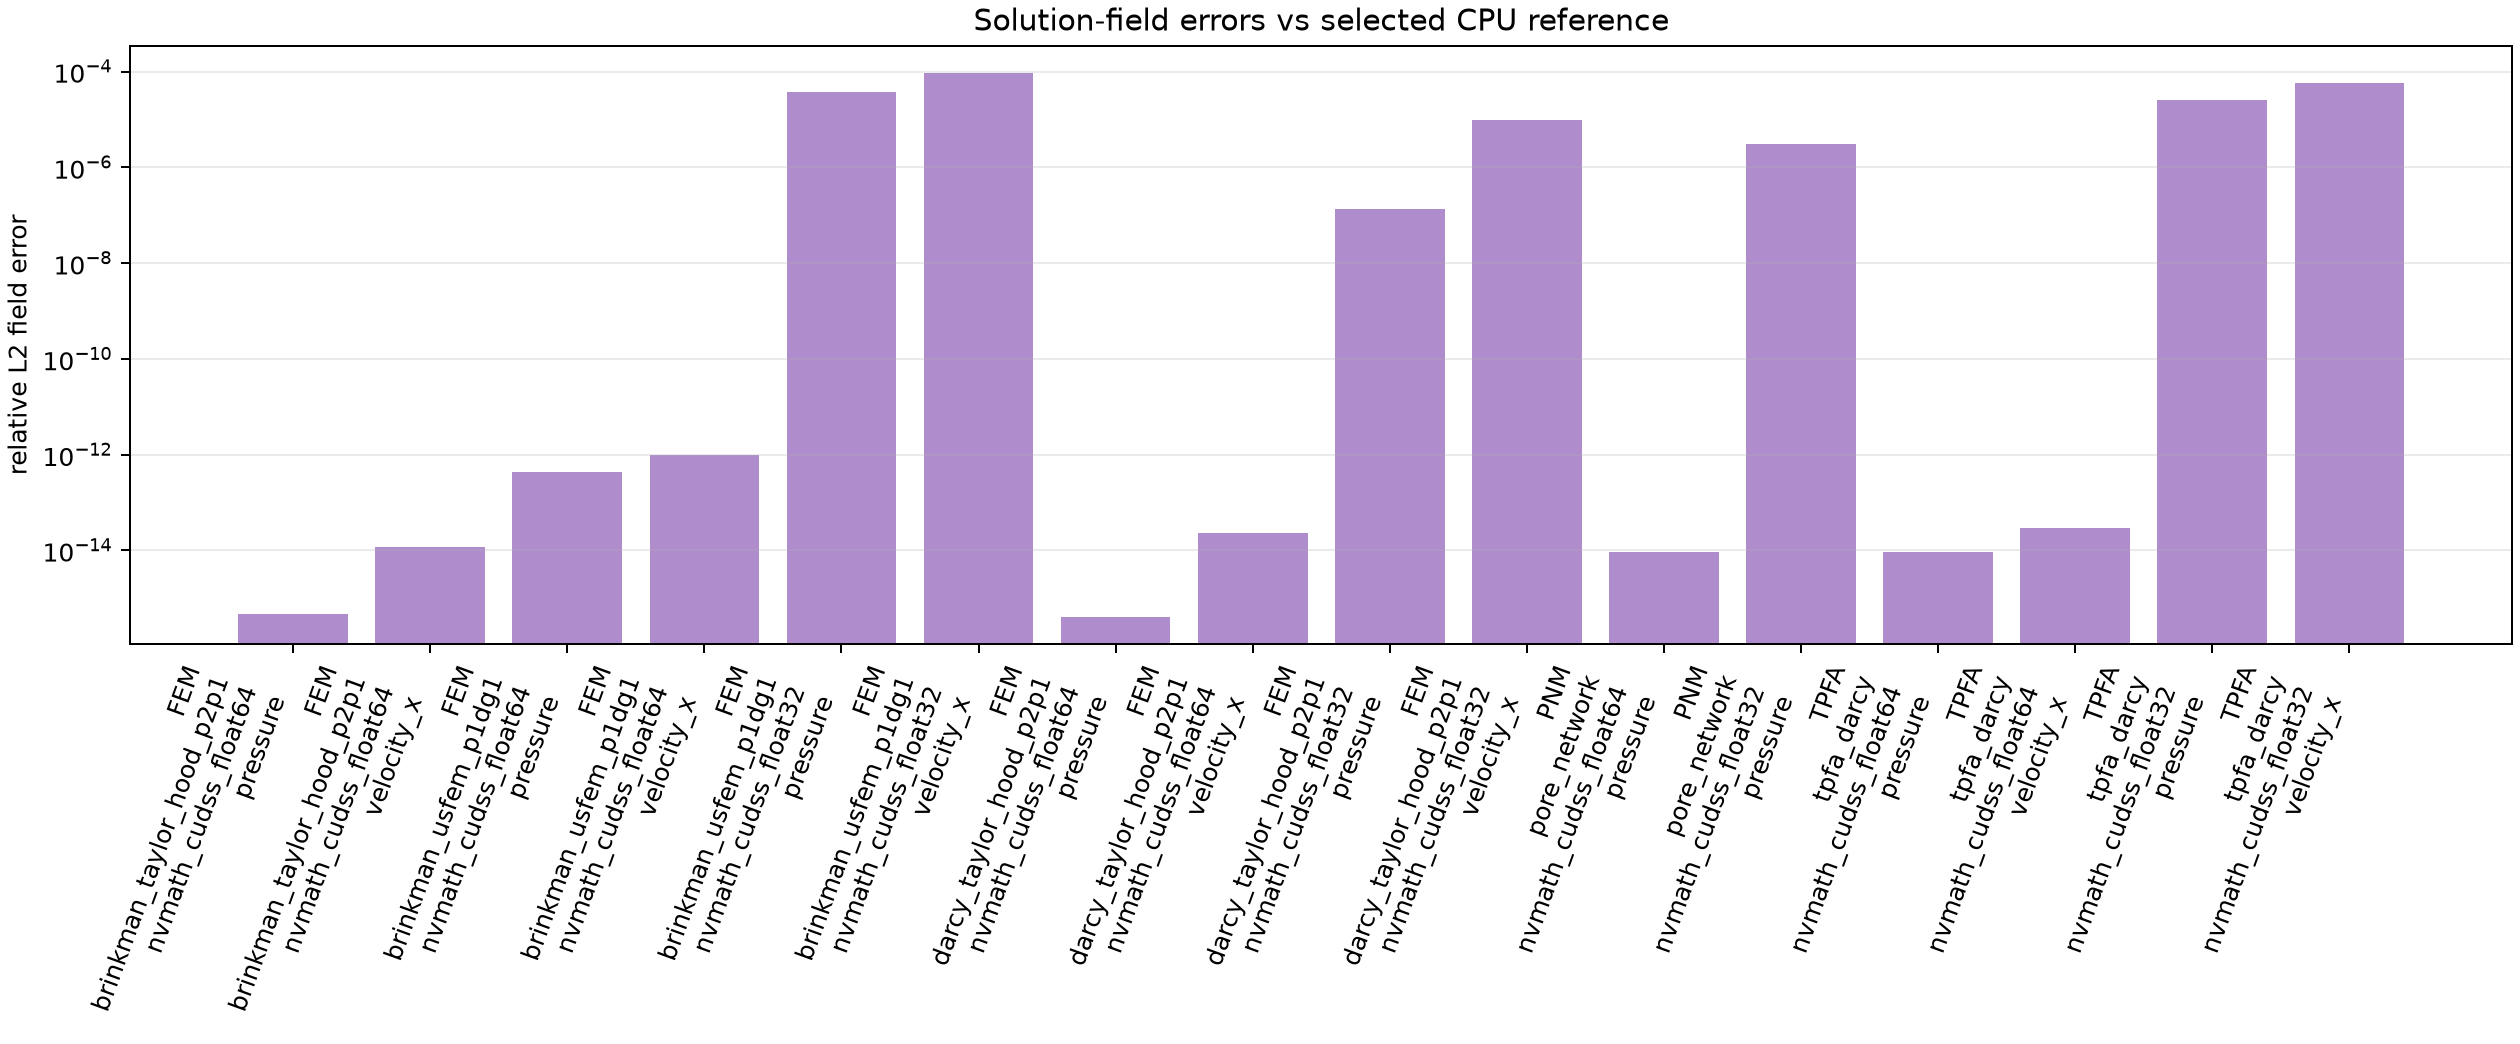

Saved field error plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_relative_l2_error.png


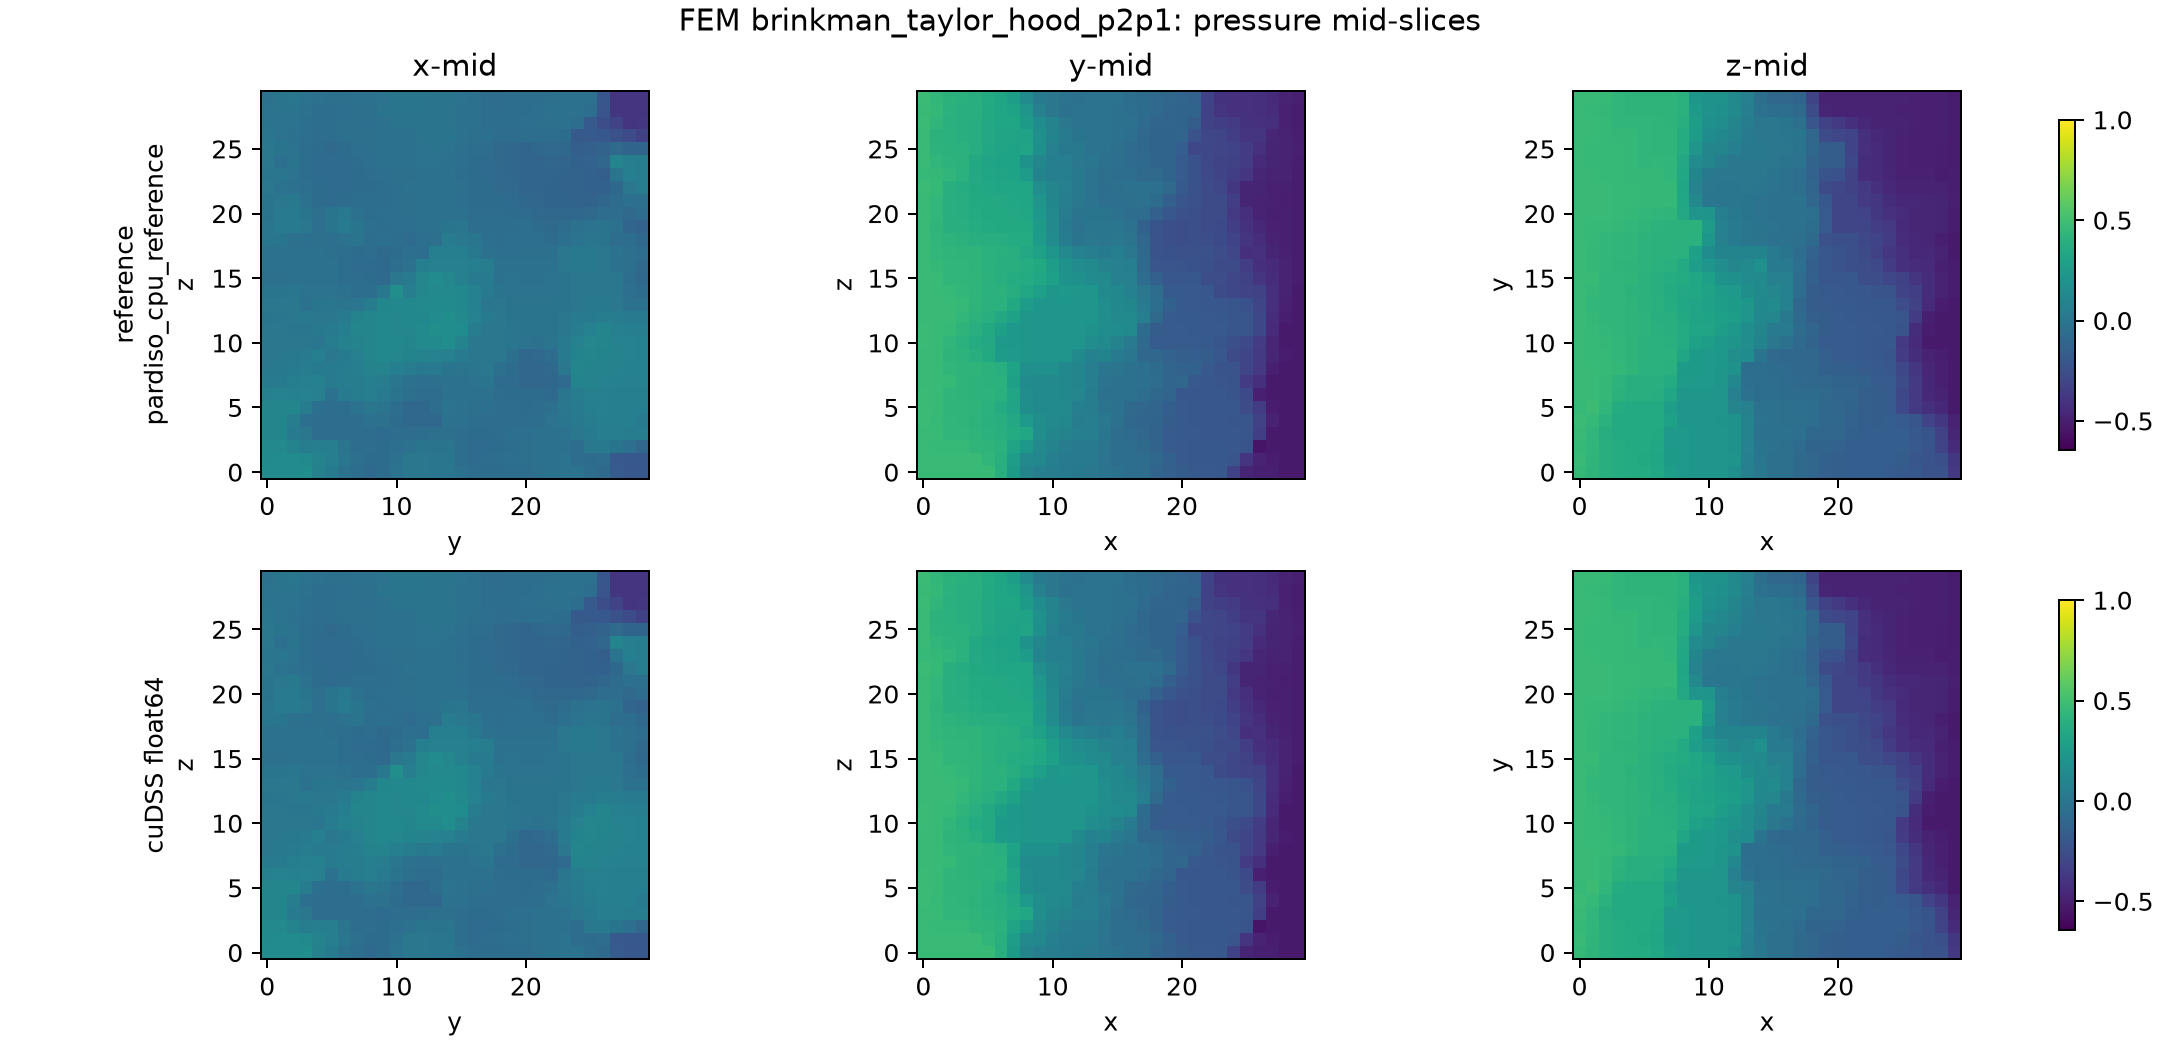

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_brinkman_taylor_hood_p2p1_pressure_field_comparison.png


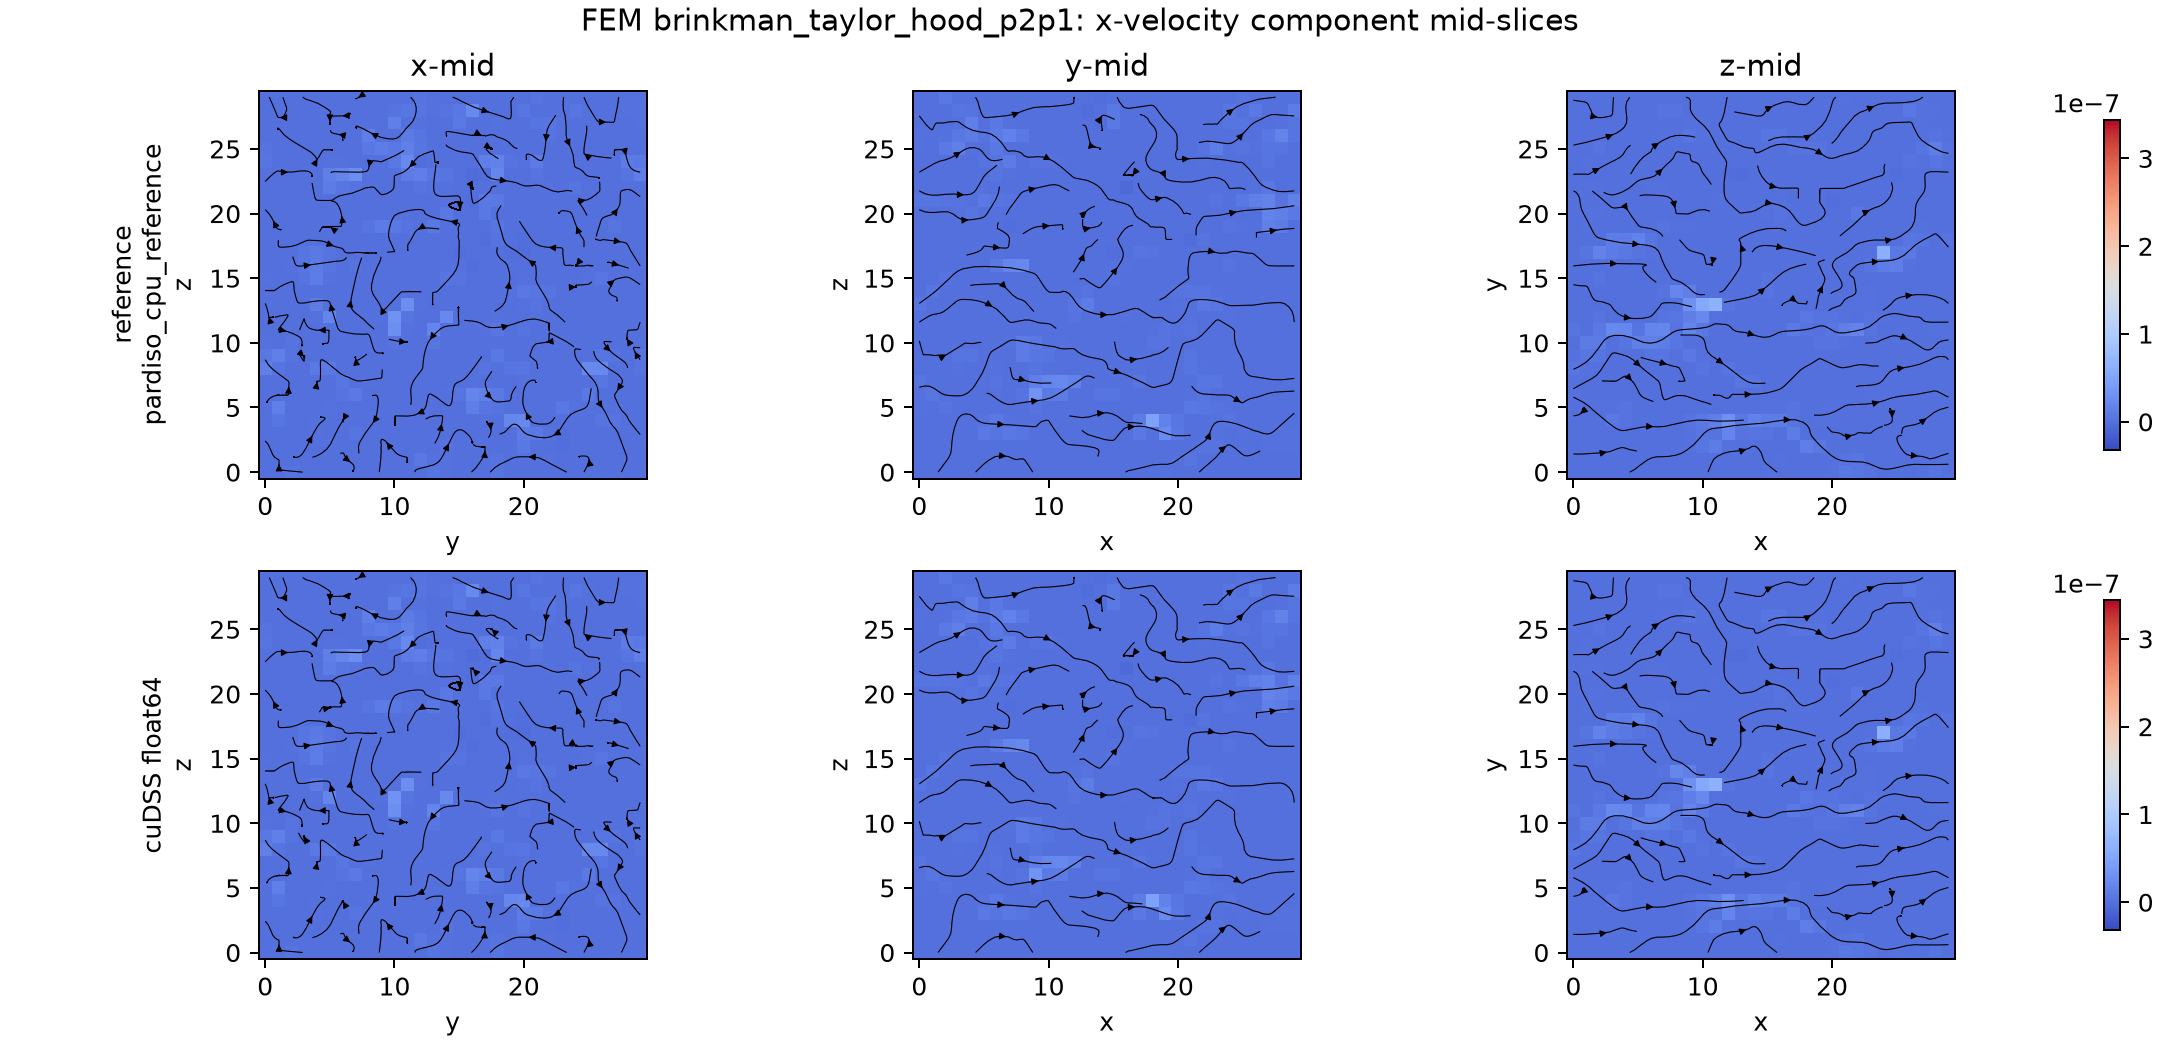

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_brinkman_taylor_hood_p2p1_velocity-x_field_comparison.png


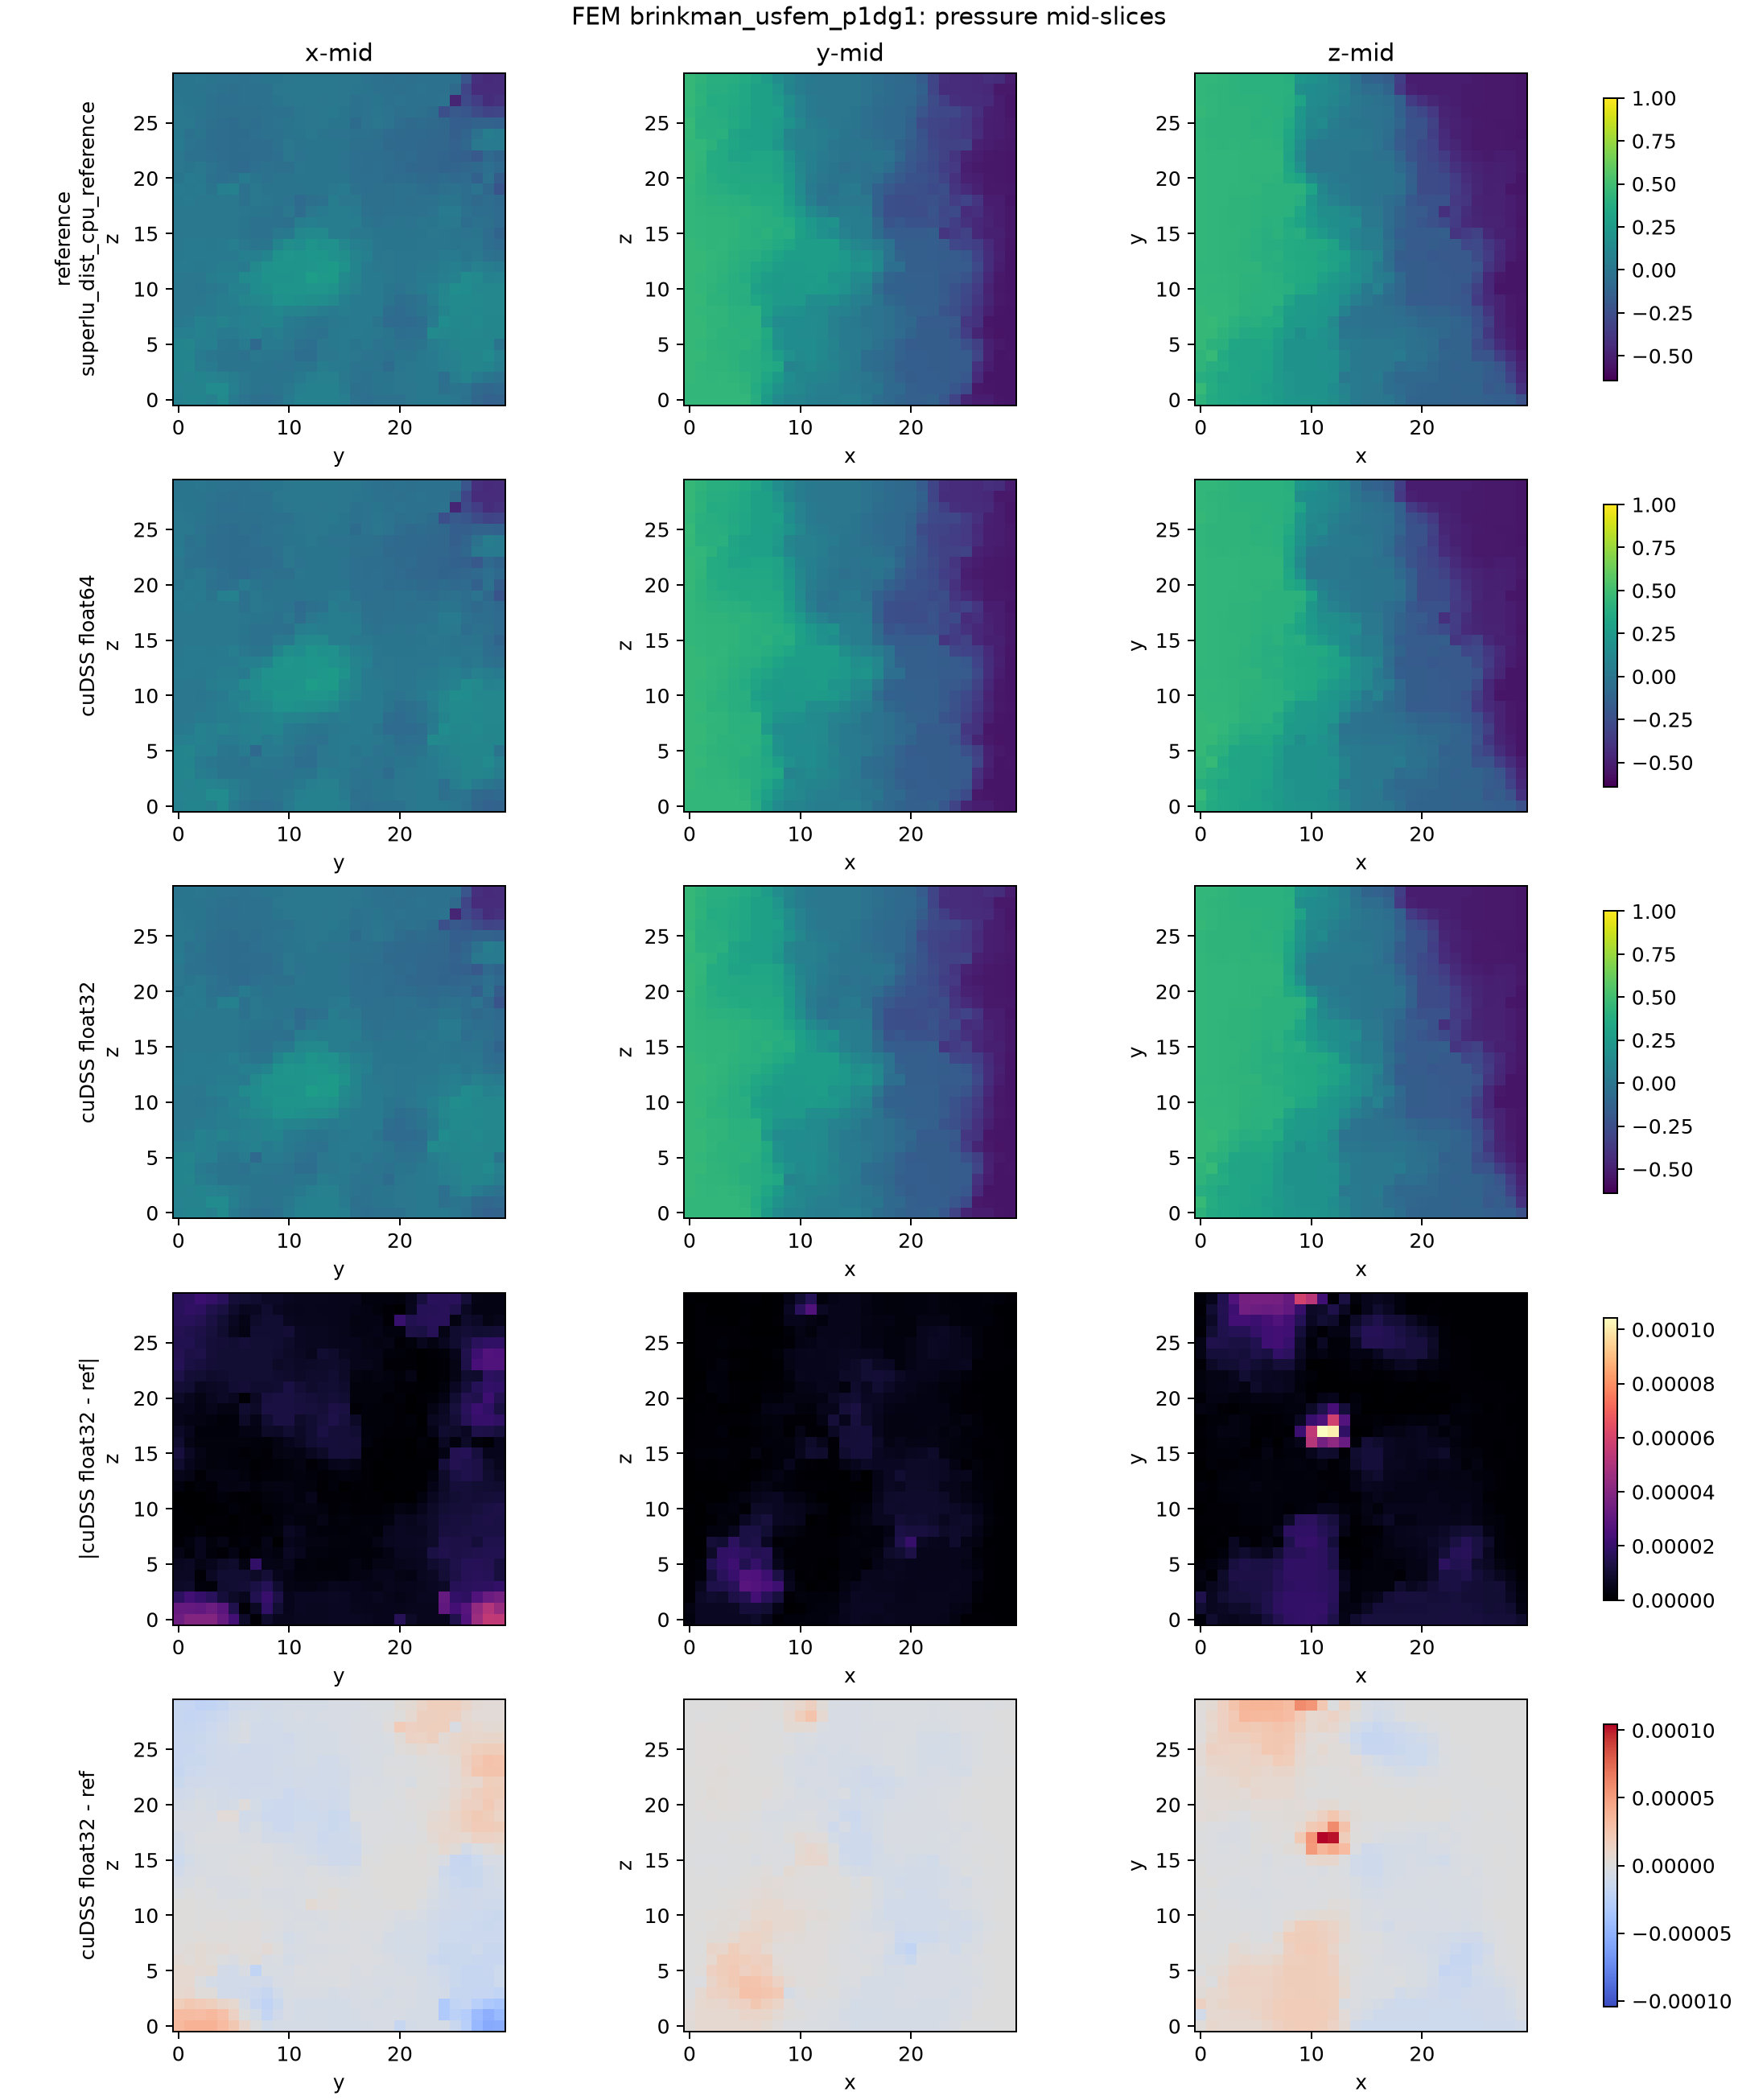

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_brinkman_usfem_p1dg1_pressure_field_comparison.png


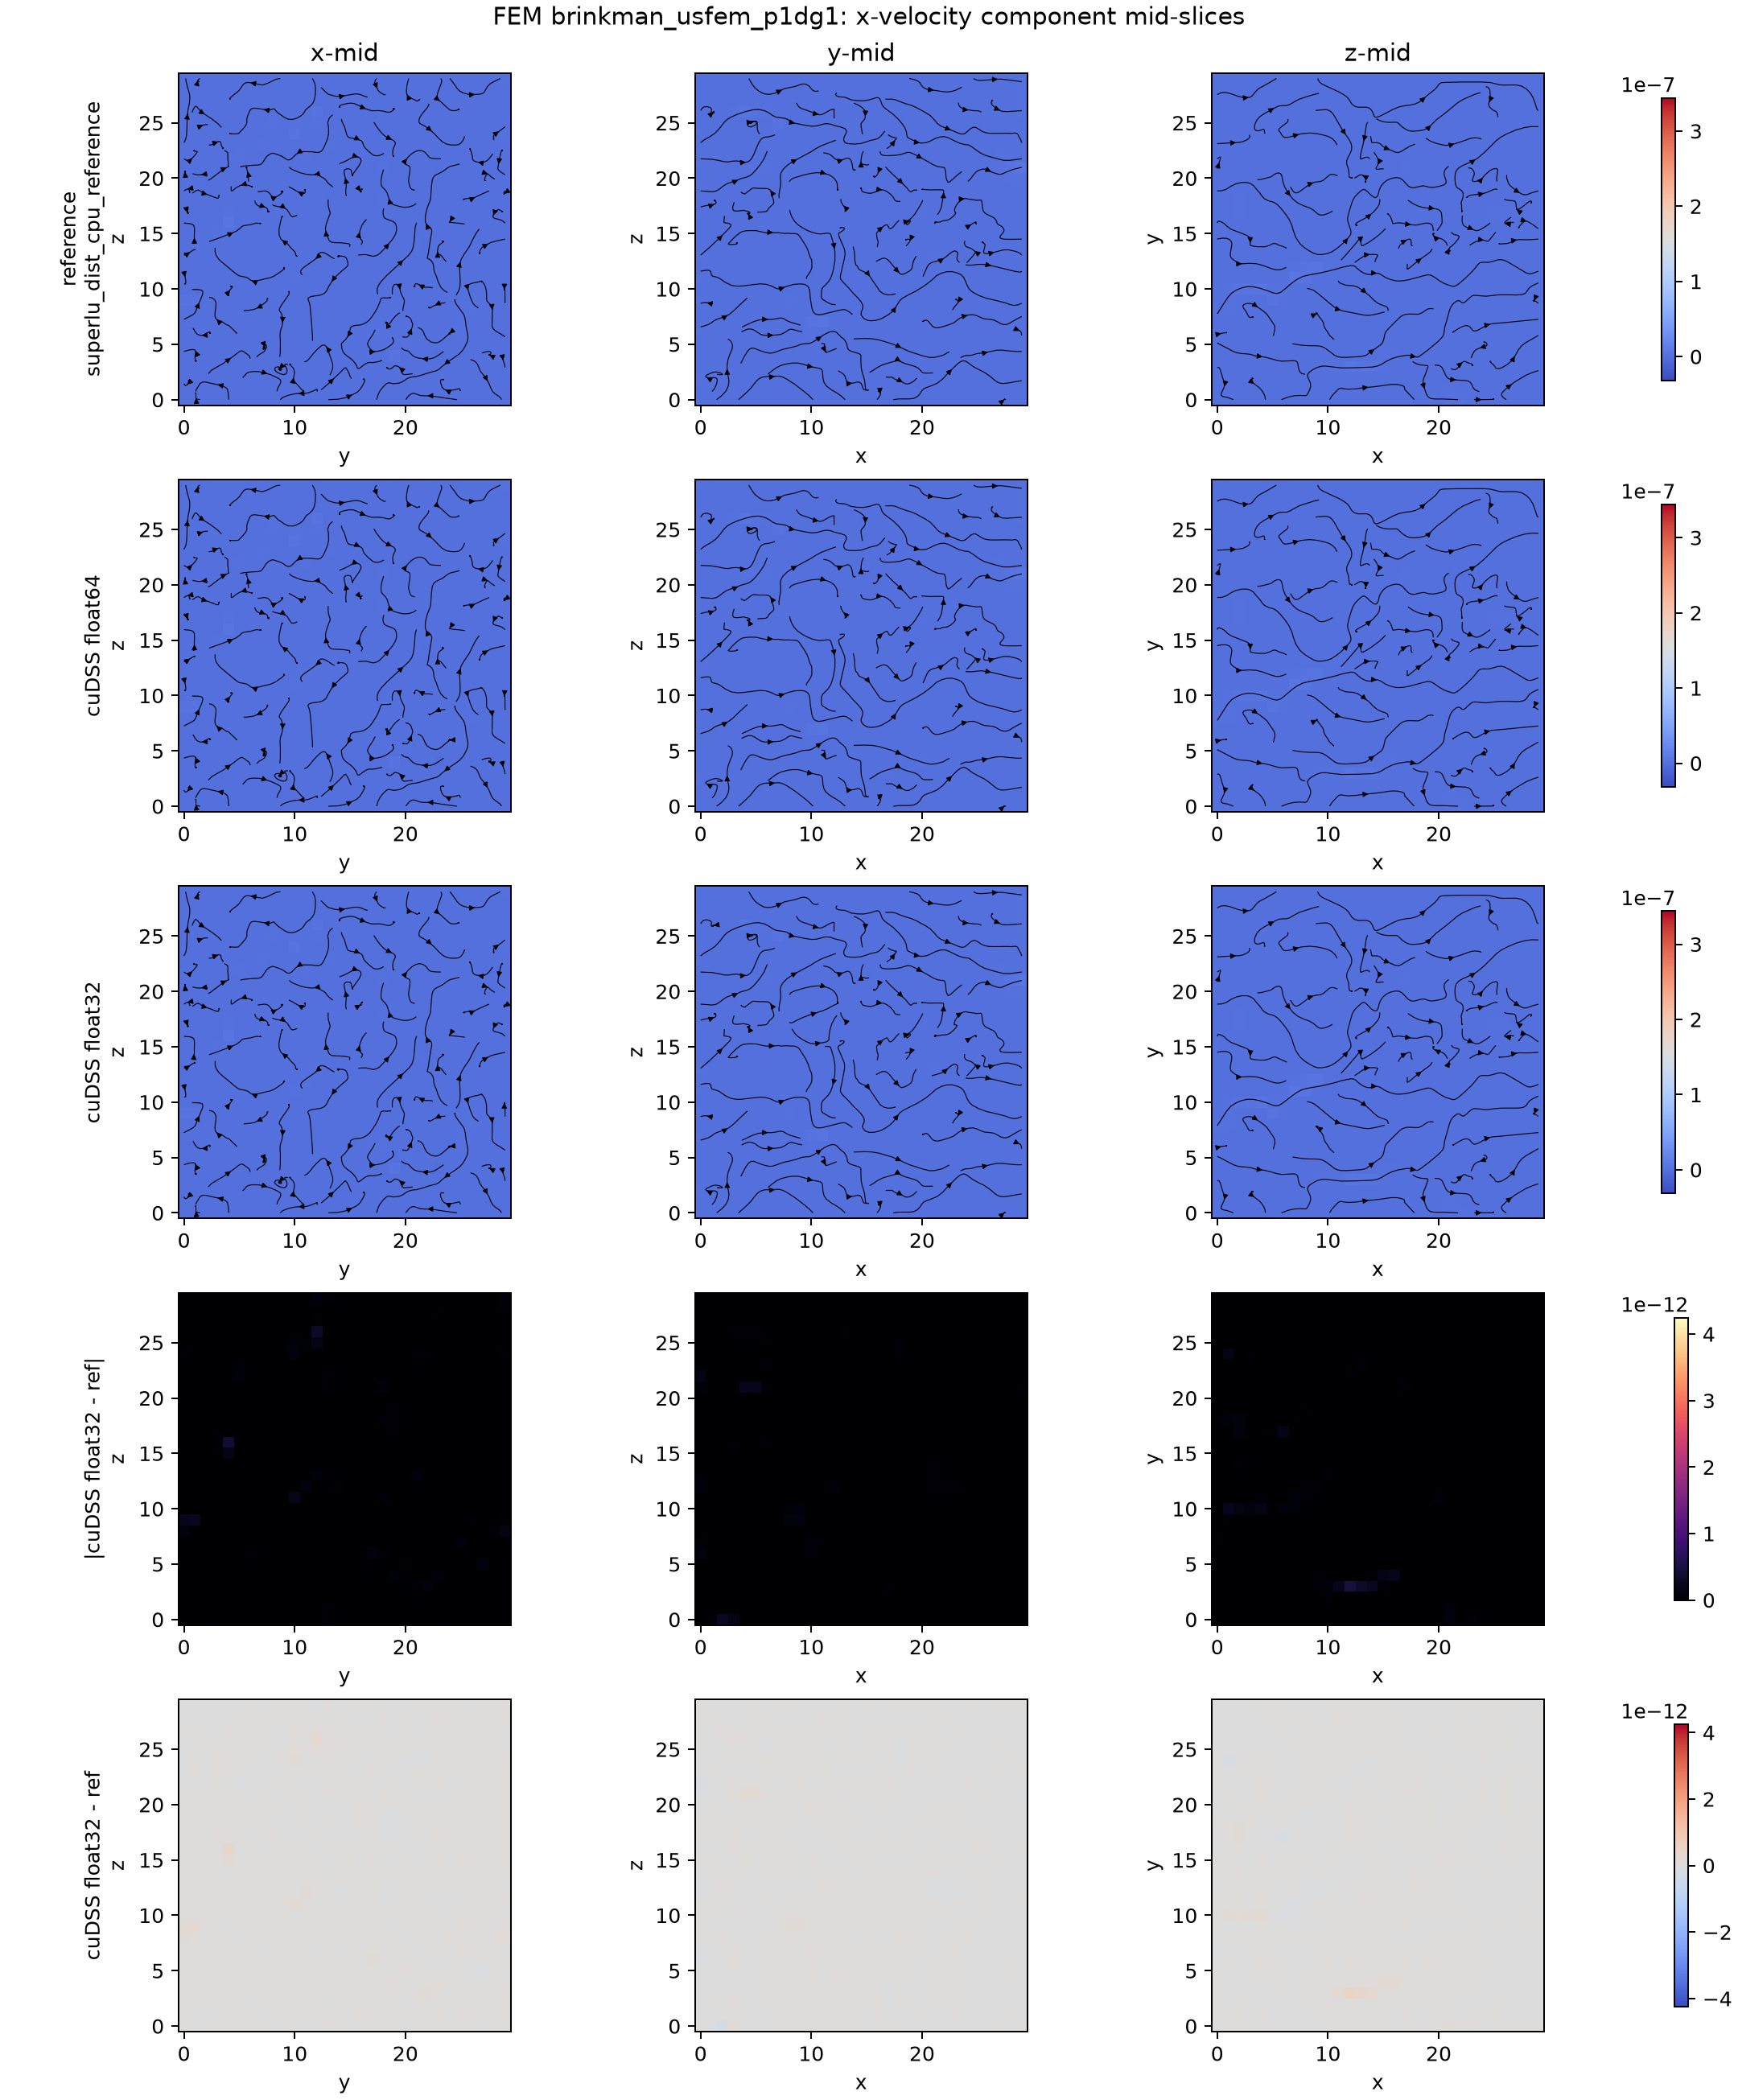

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_brinkman_usfem_p1dg1_velocity-x_field_comparison.png


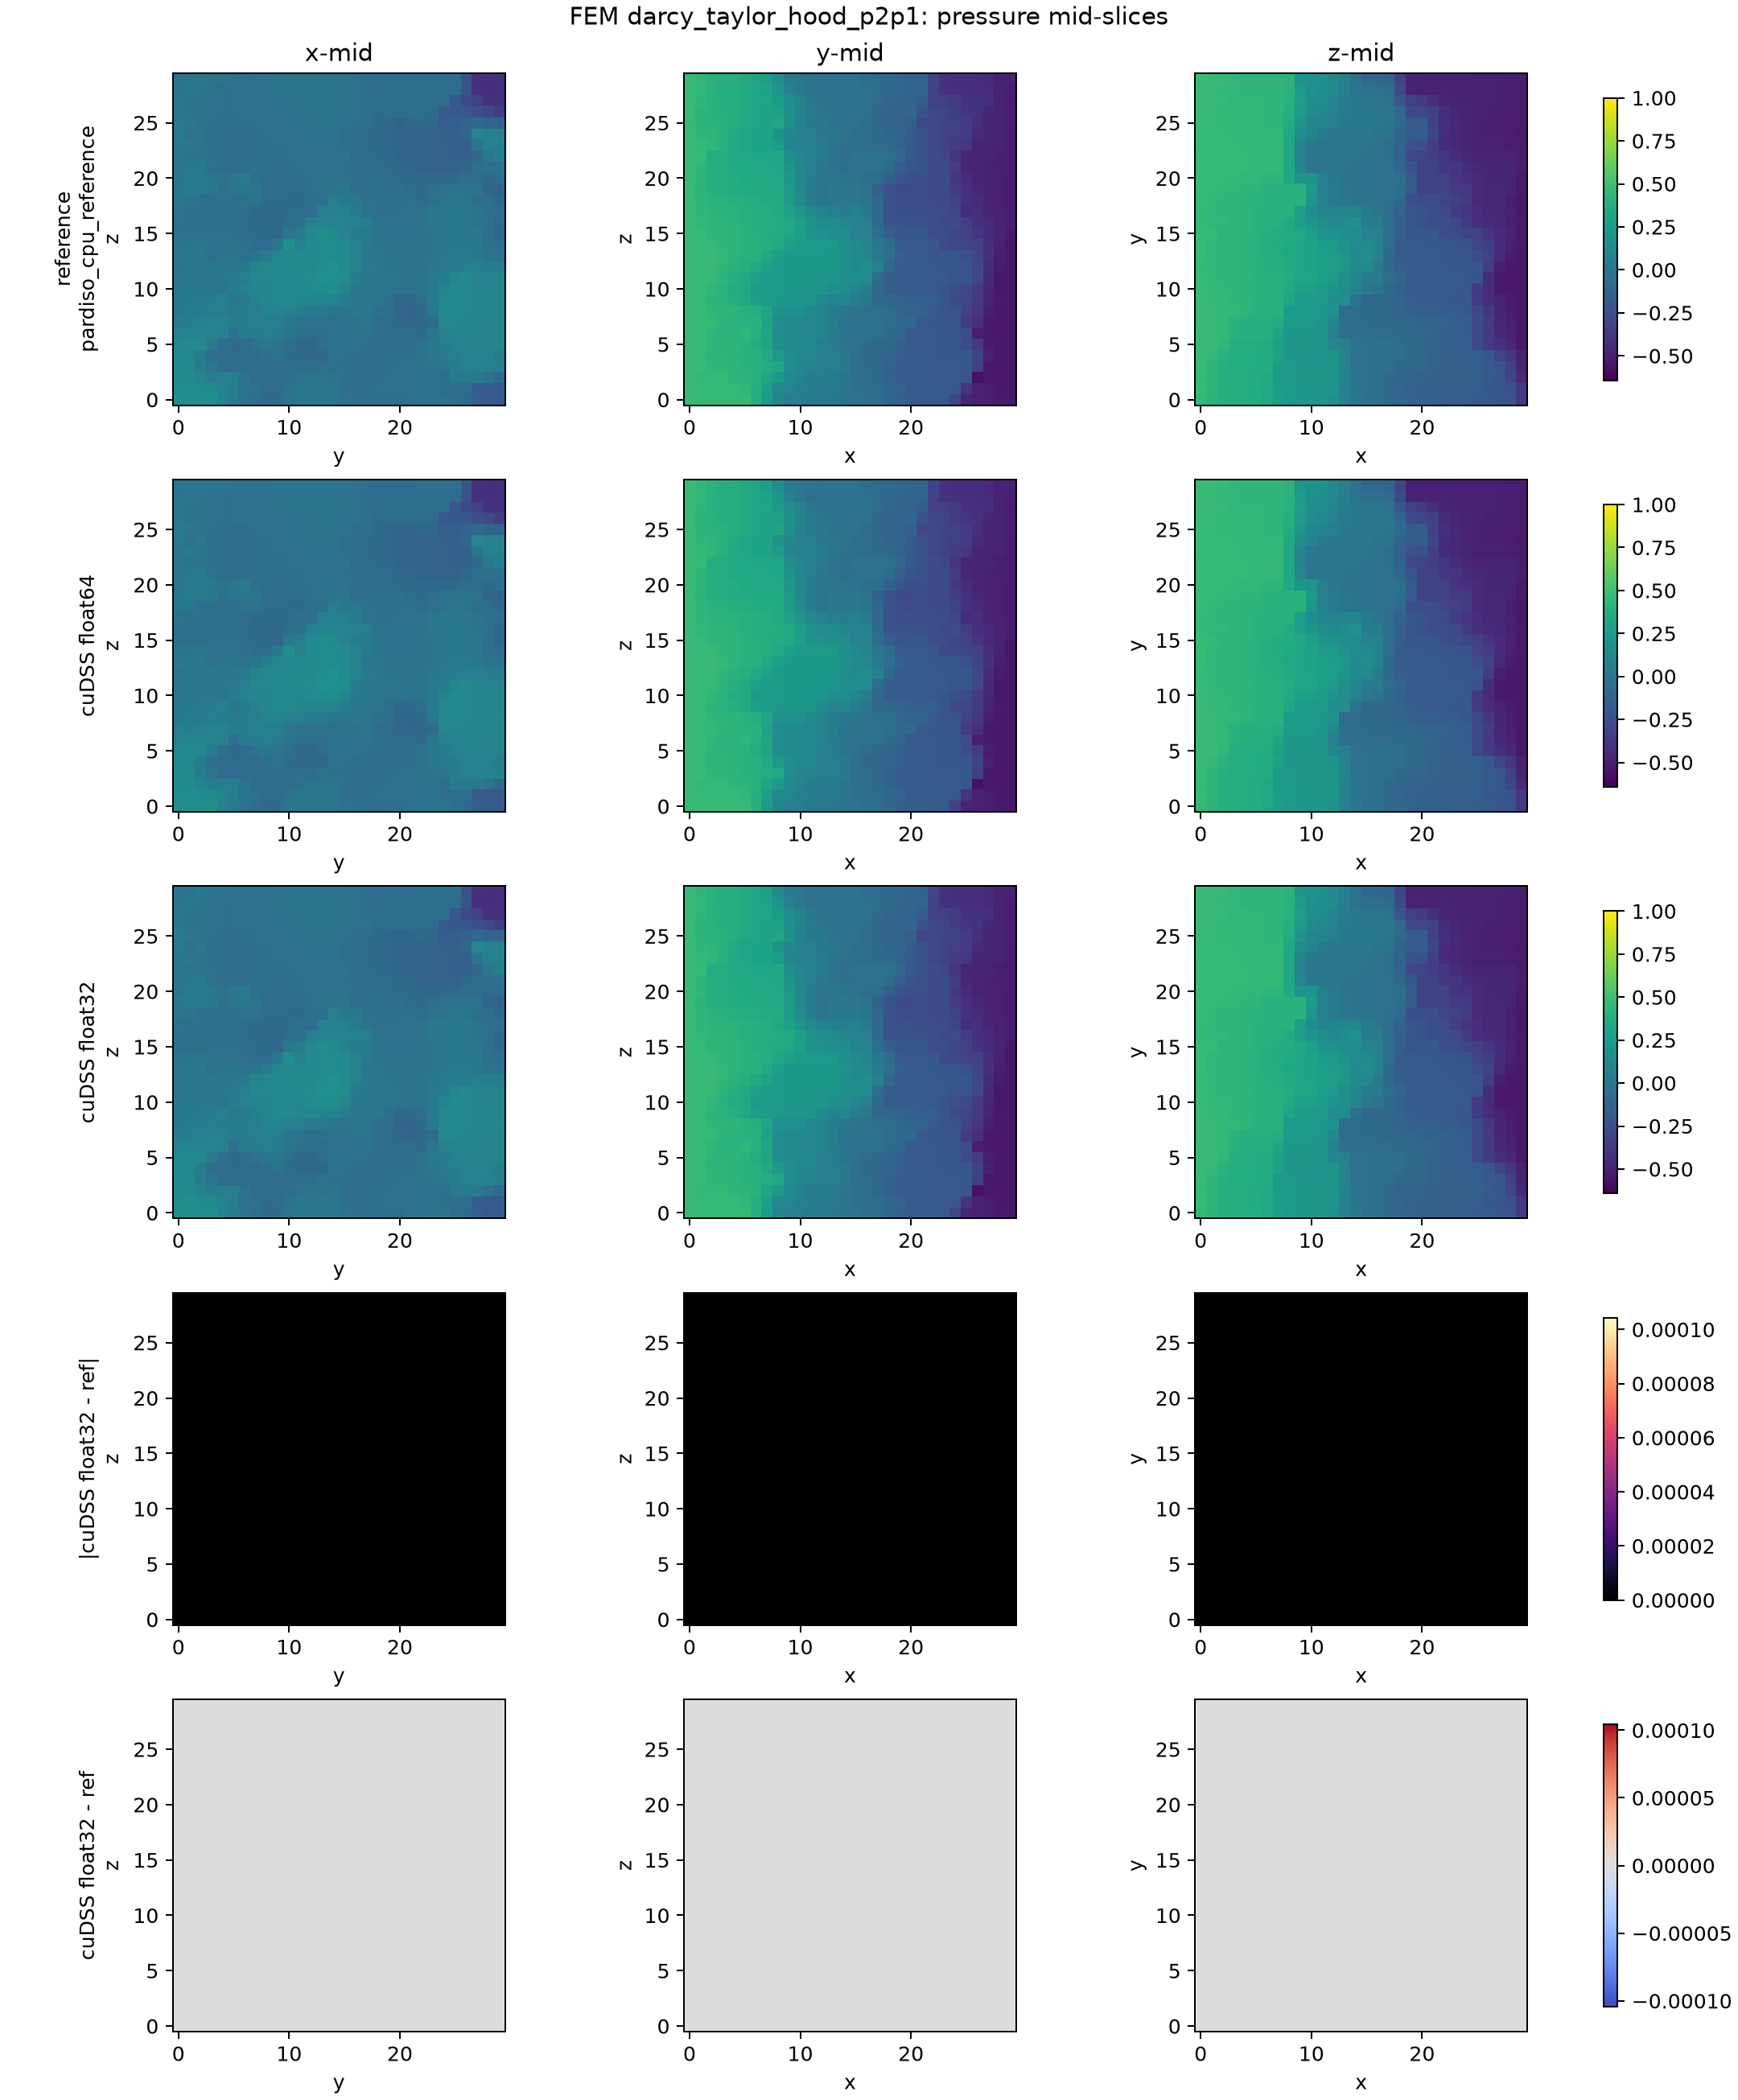

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_darcy_taylor_hood_p2p1_pressure_field_comparison.png


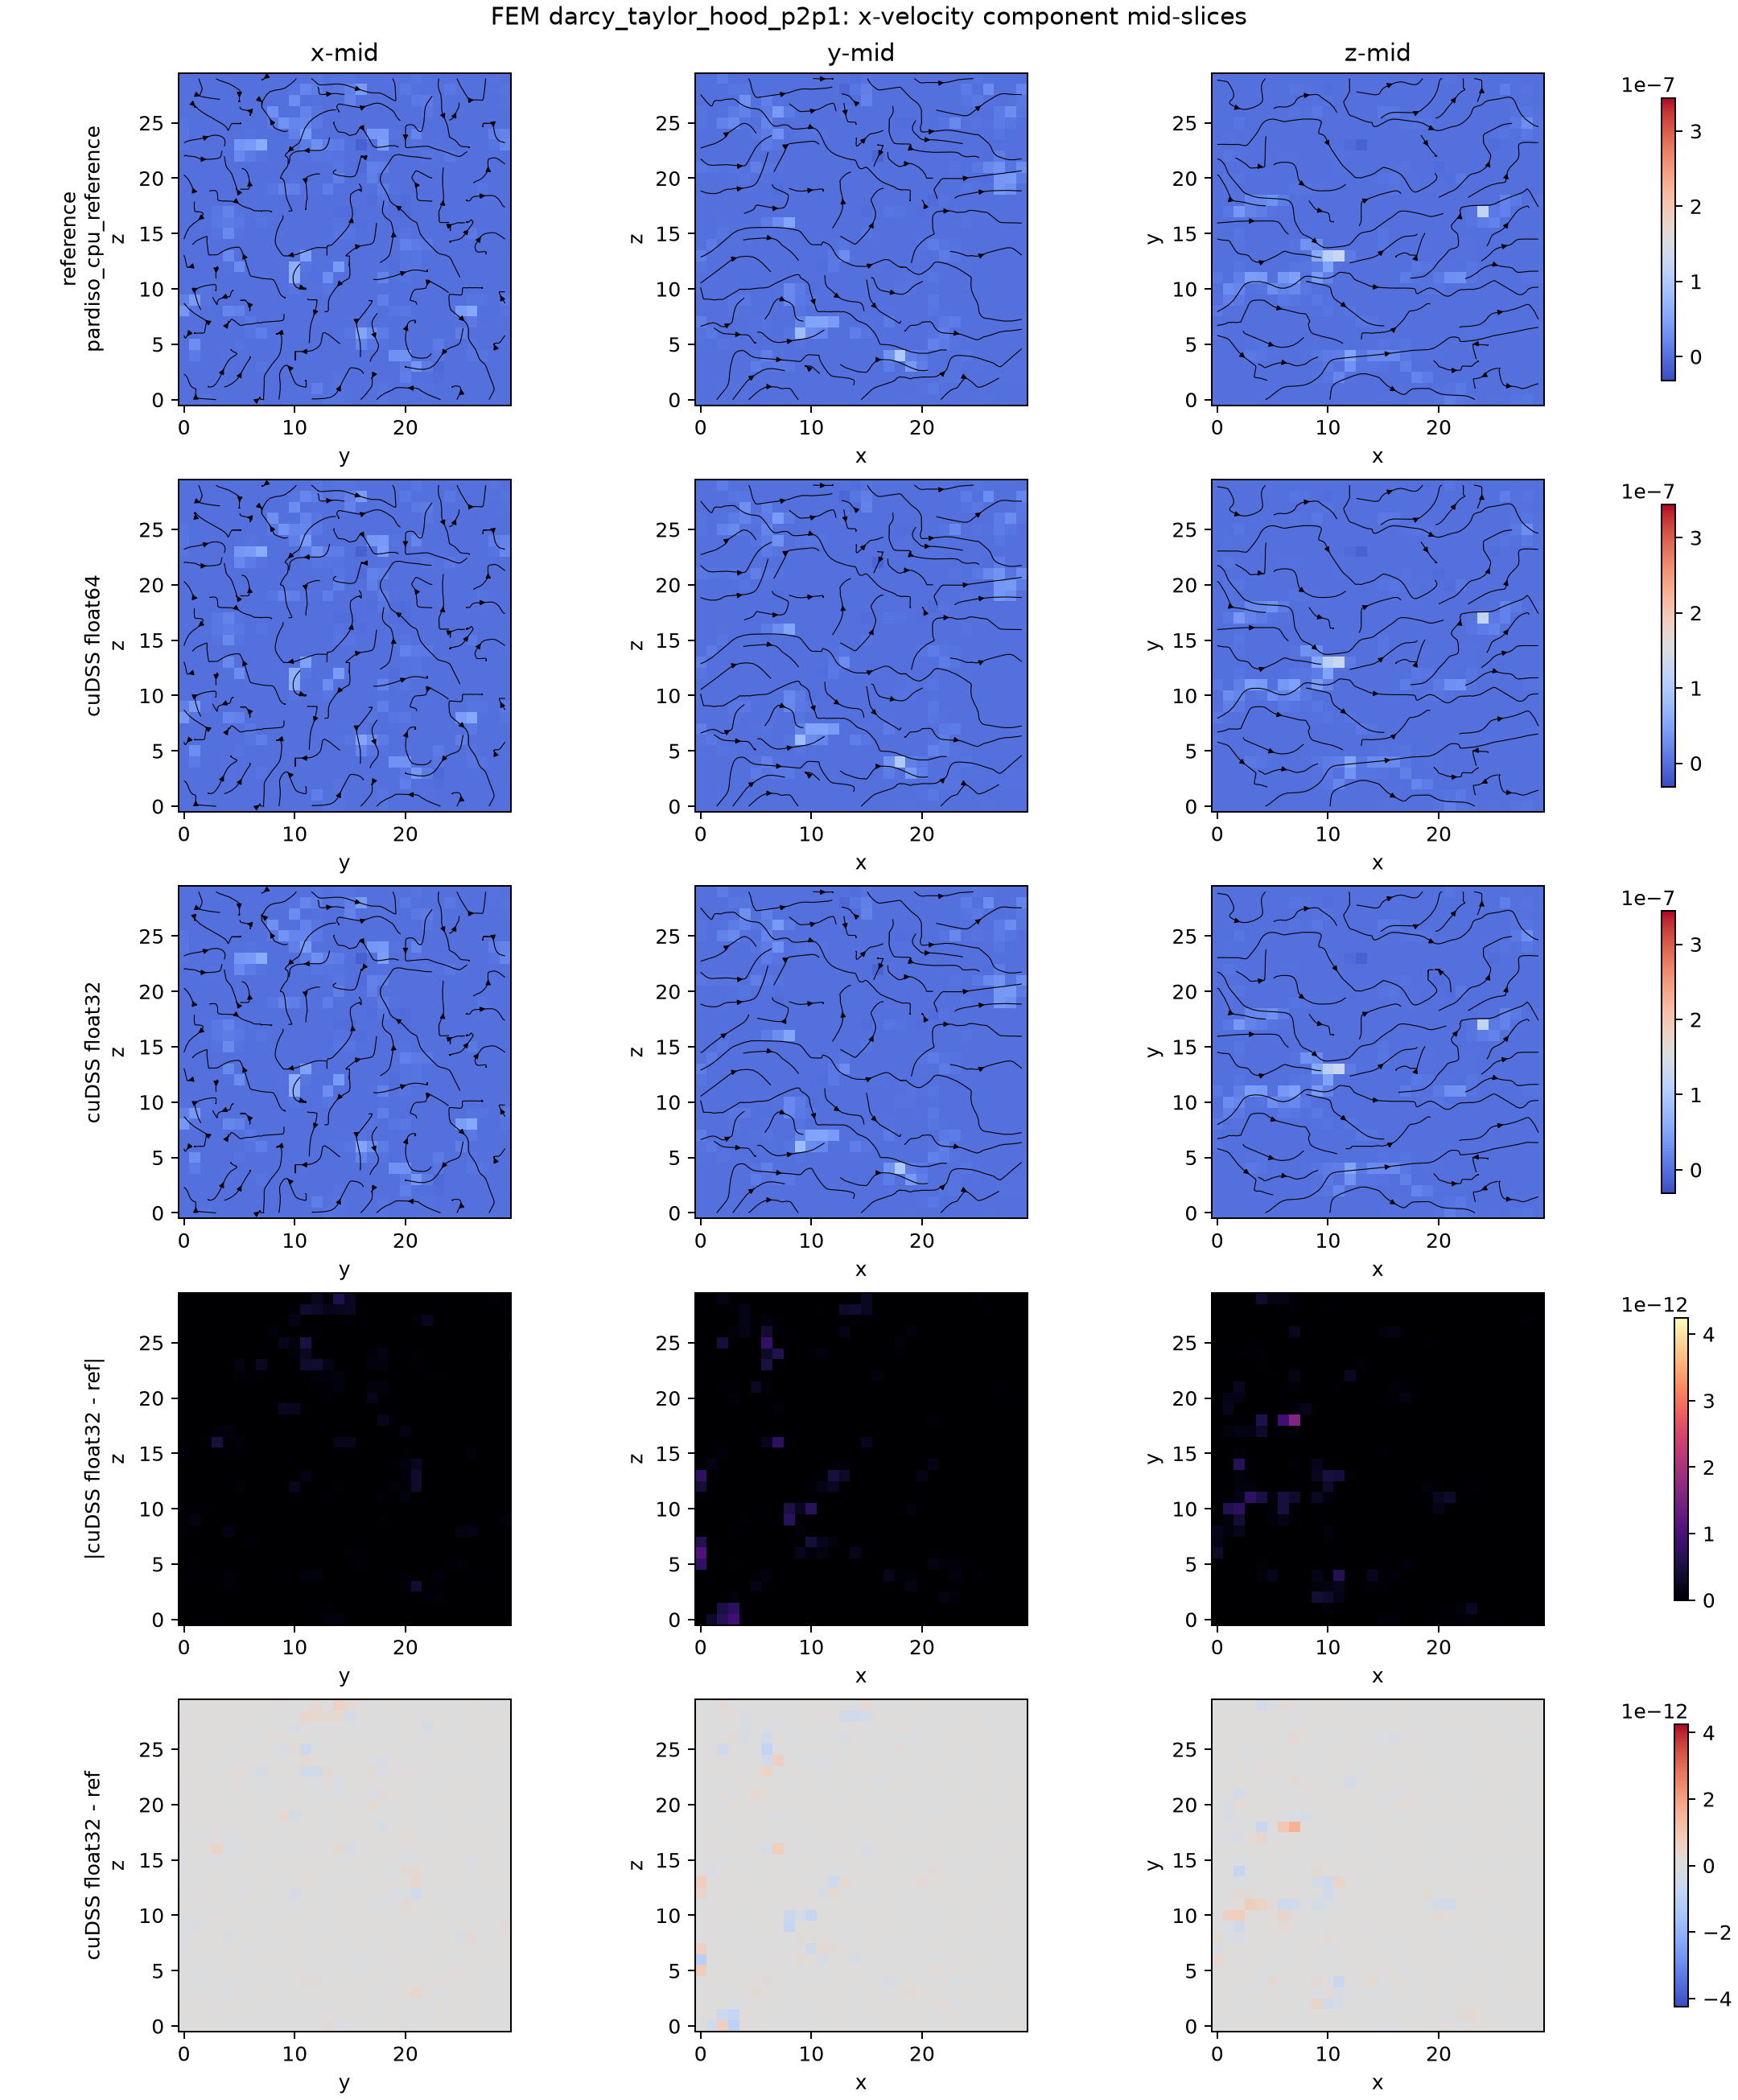

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/FEM_darcy_taylor_hood_p2p1_velocity-x_field_comparison.png


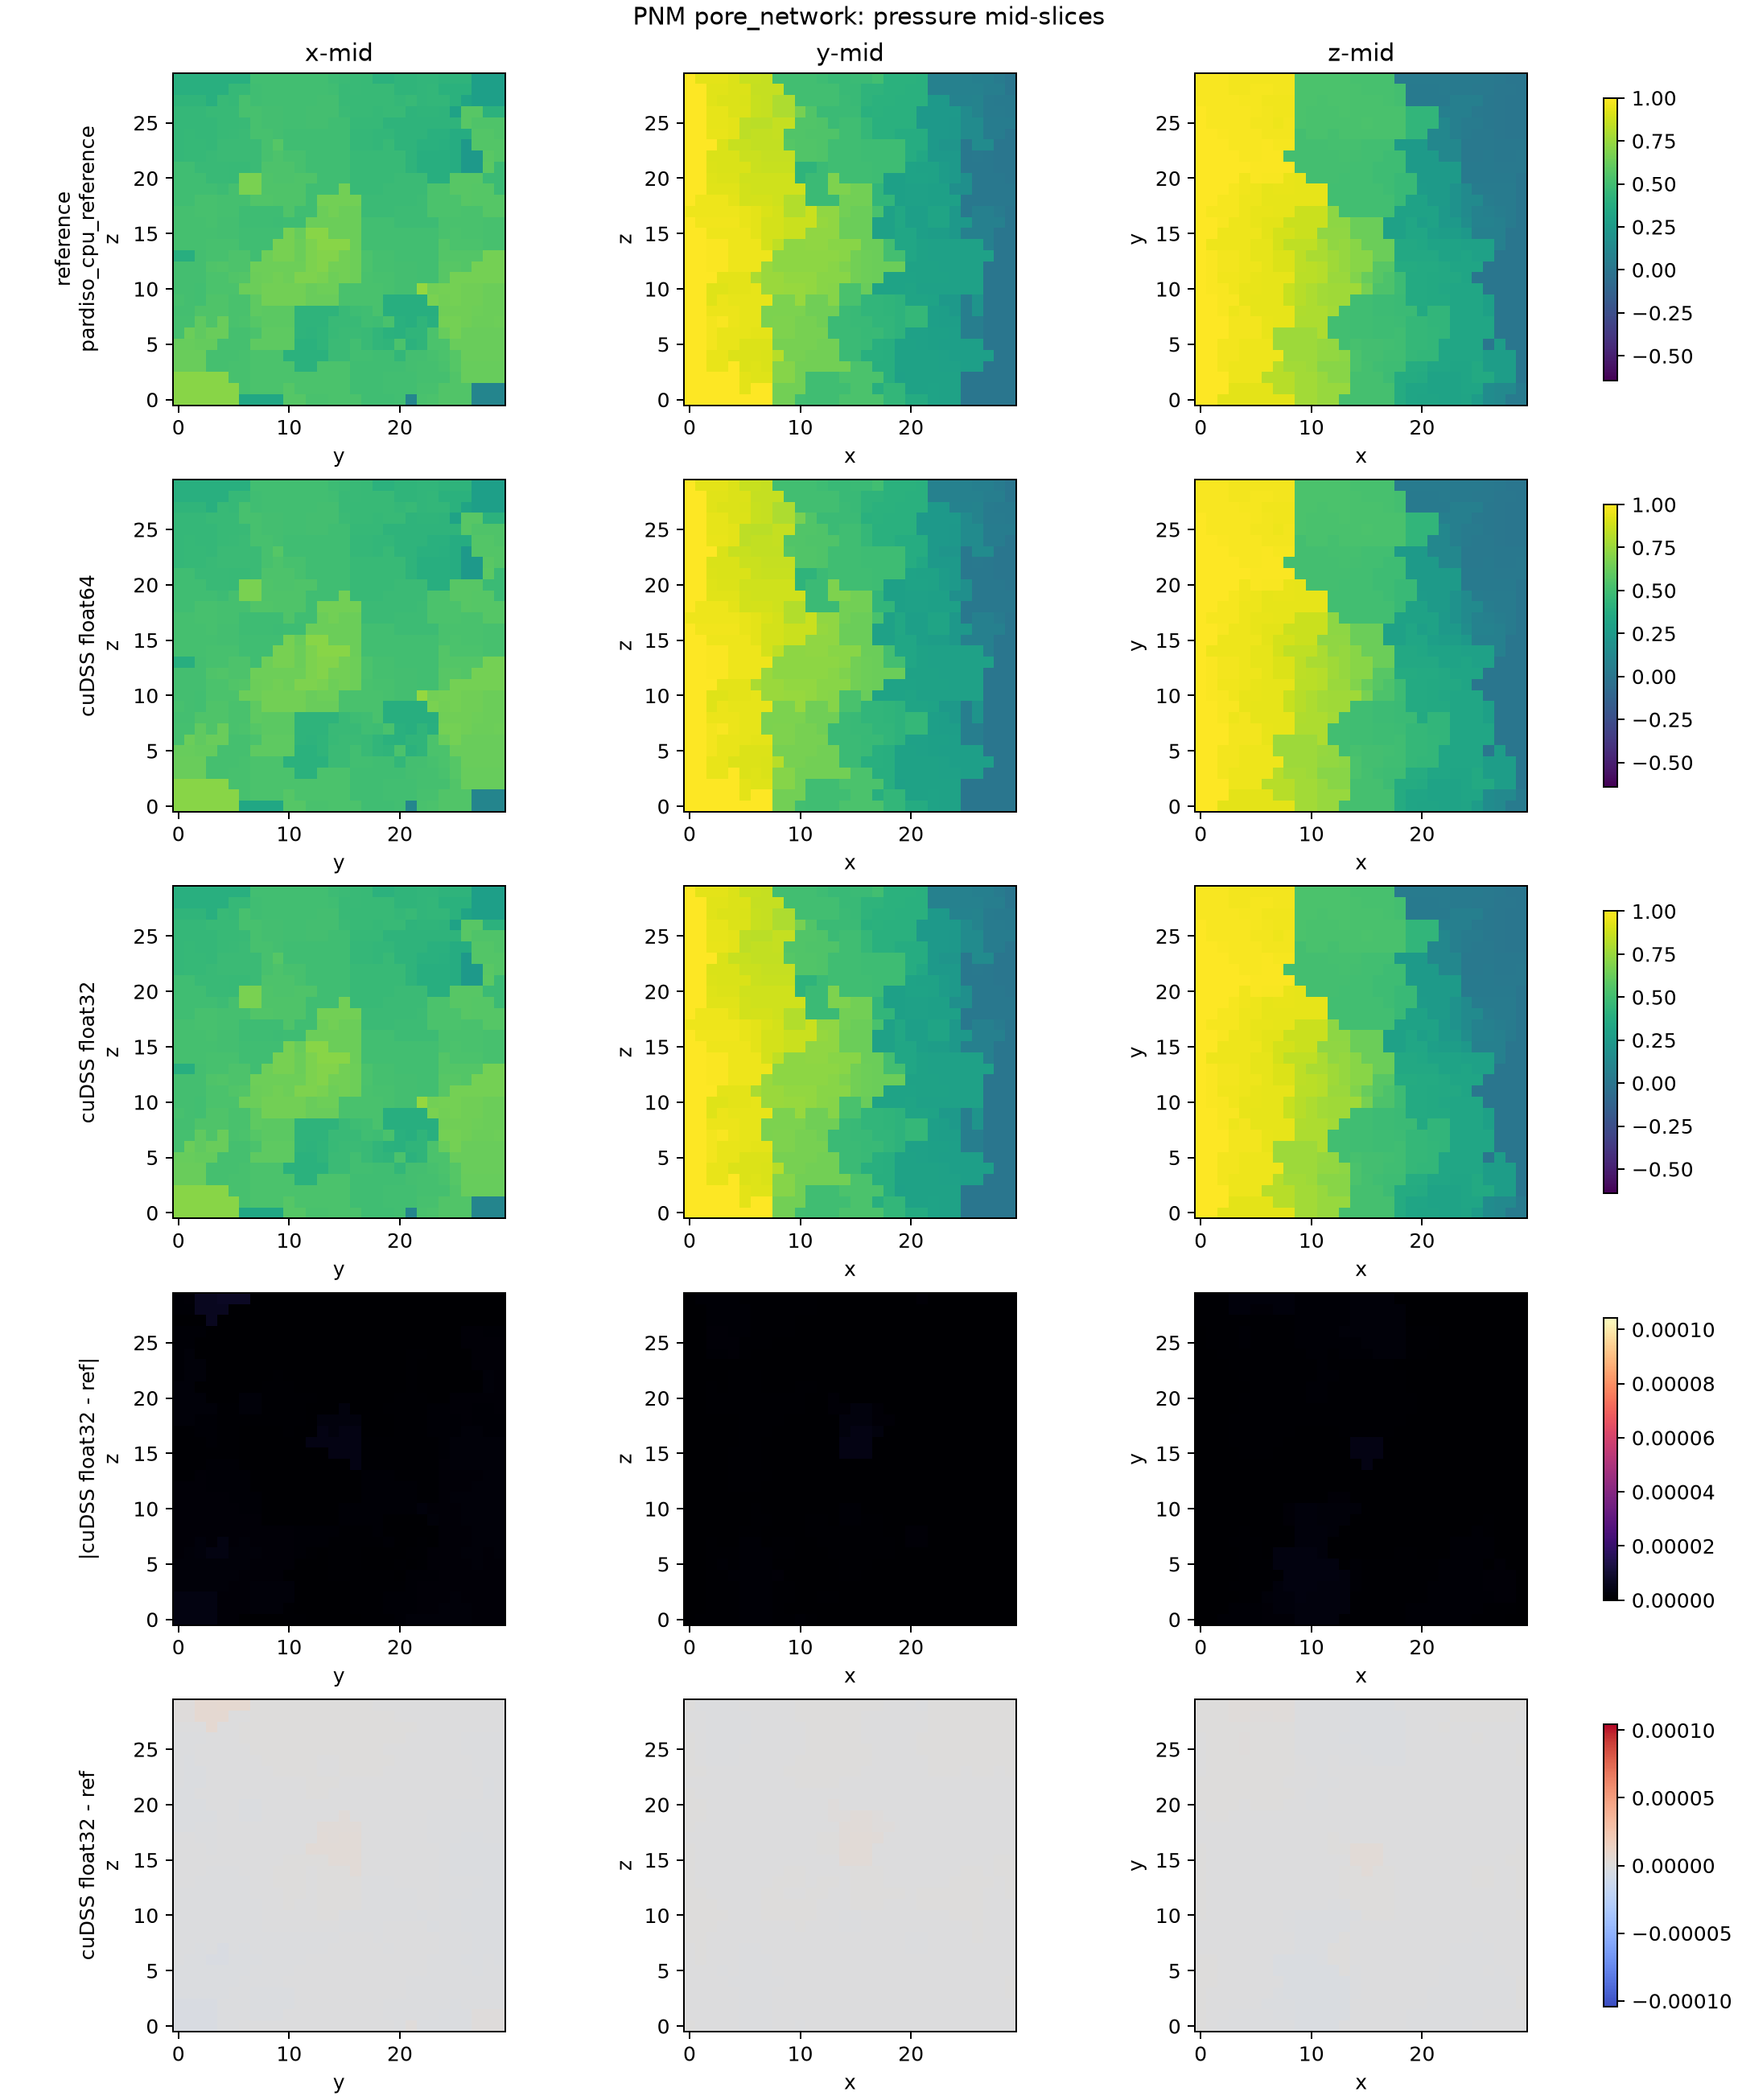

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/PNM_pore_network_pressure_field_comparison.png


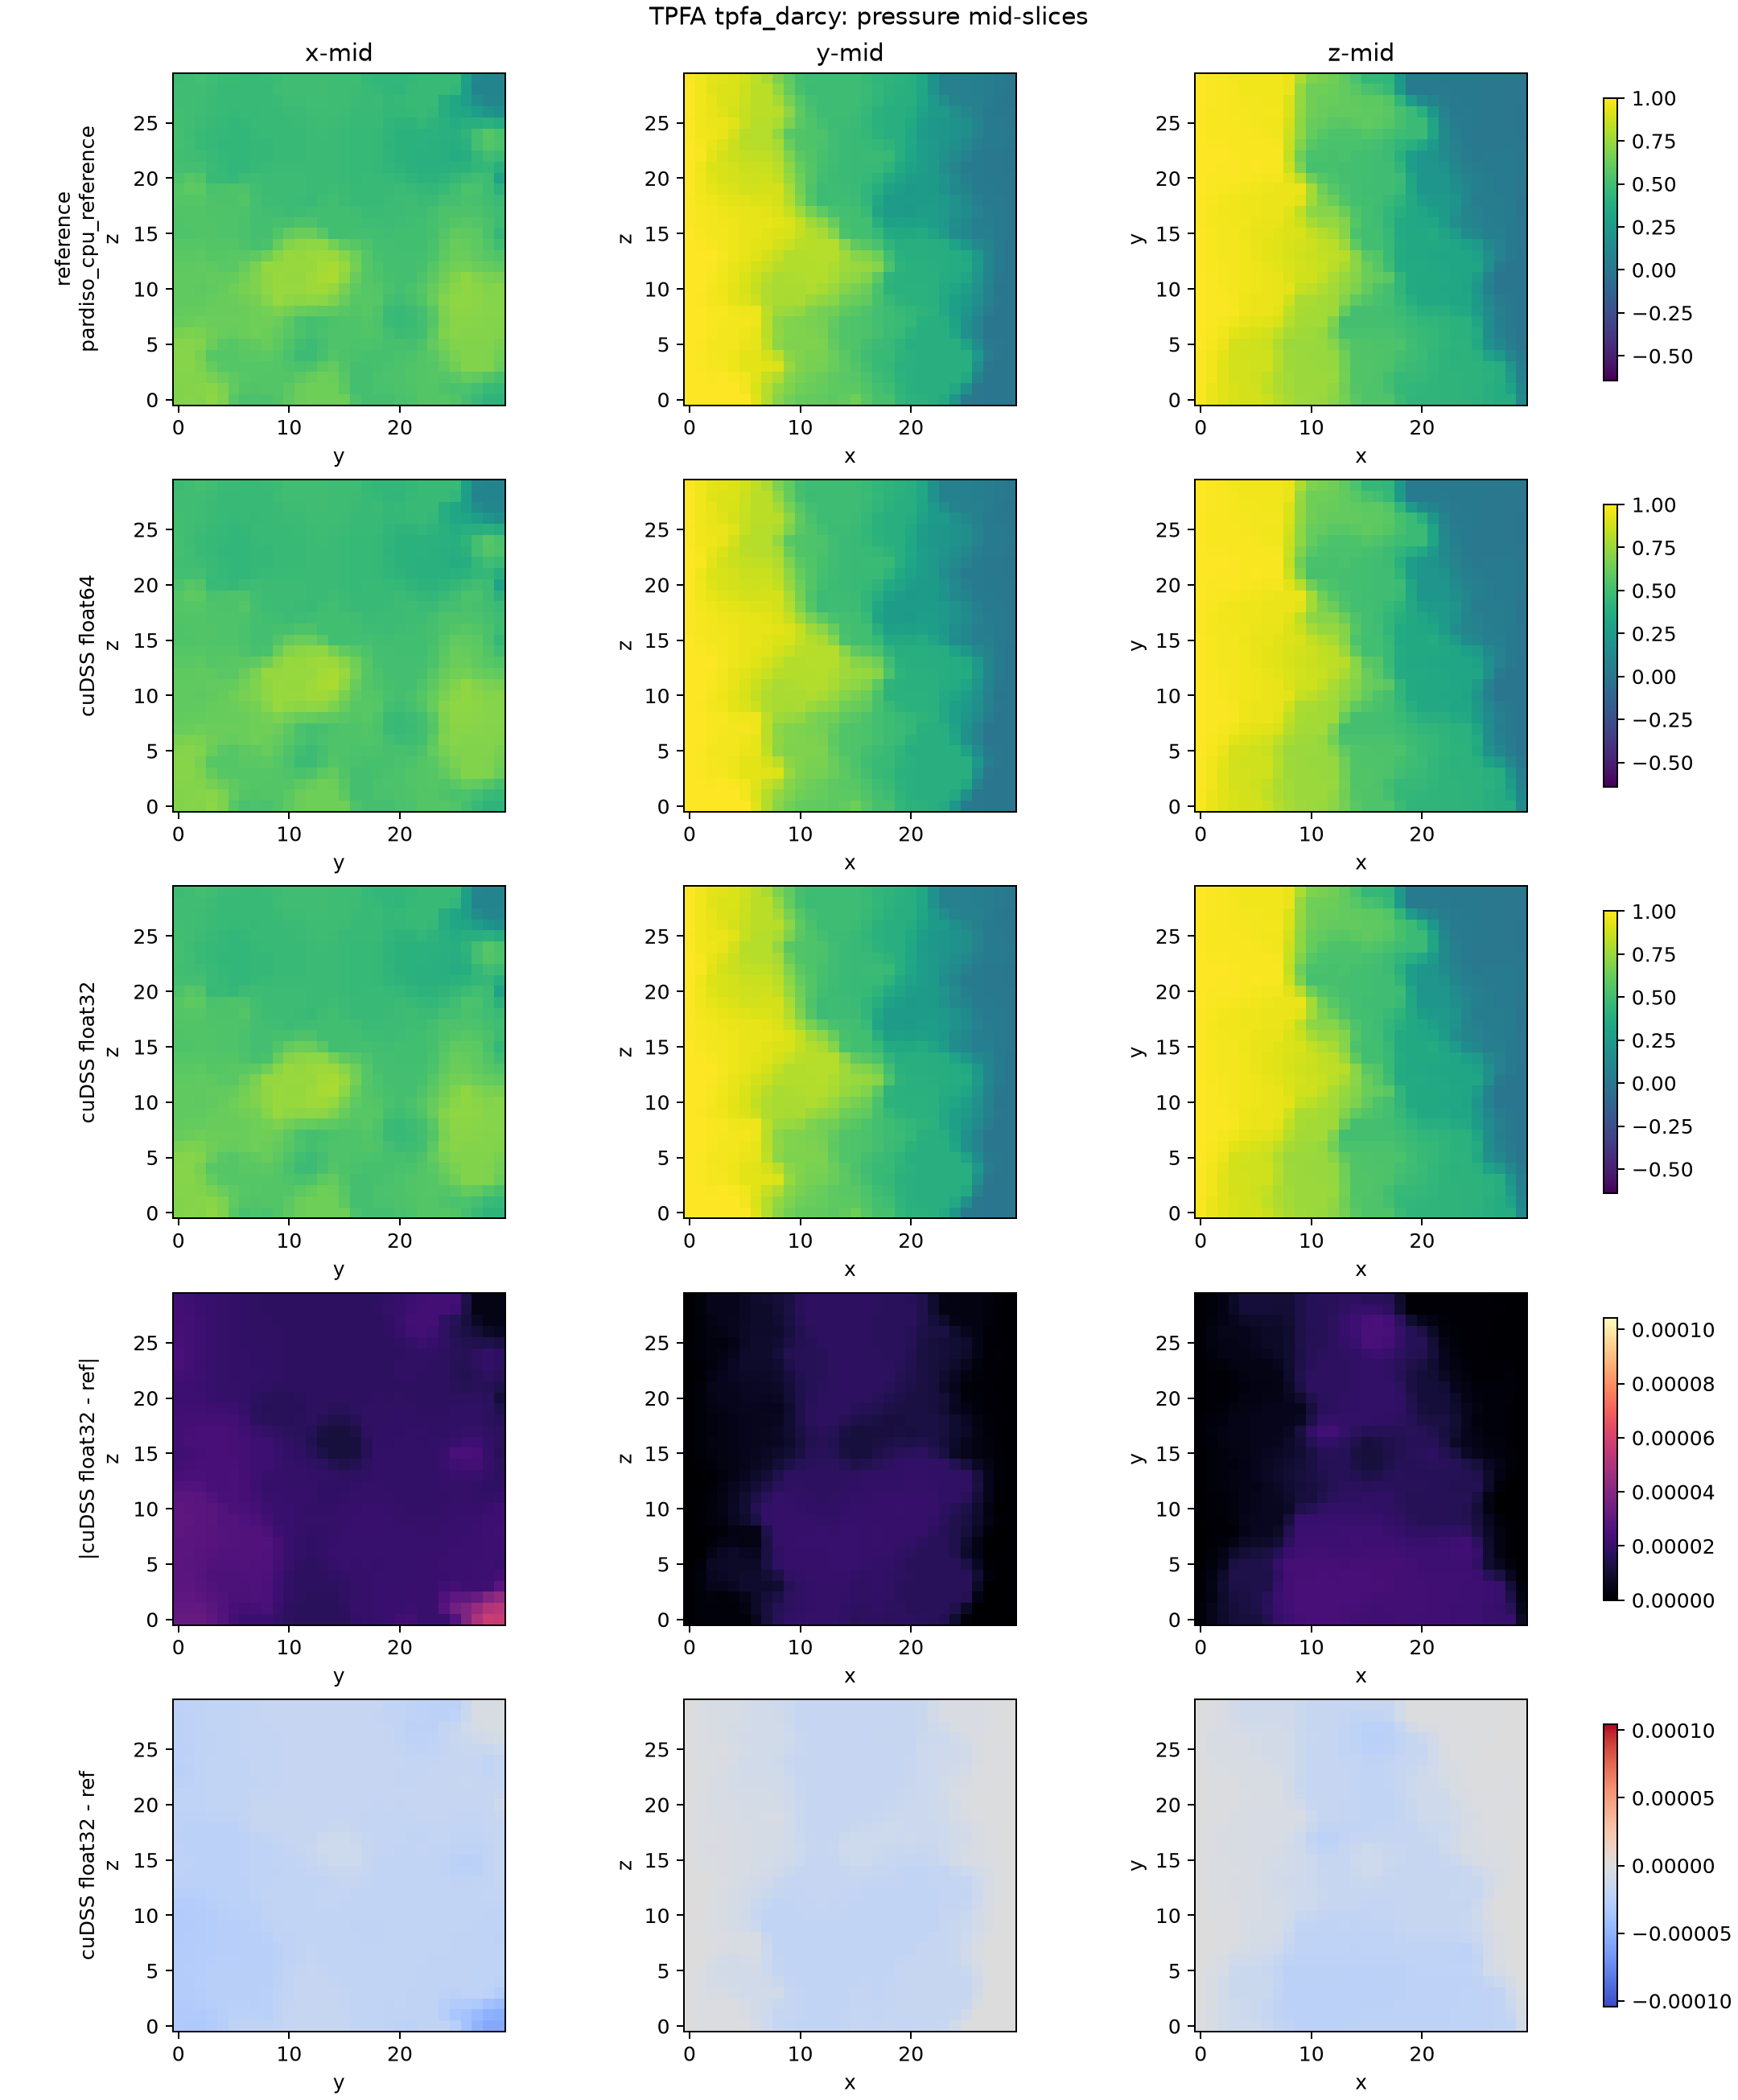

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/TPFA_tpfa_darcy_pressure_field_comparison.png


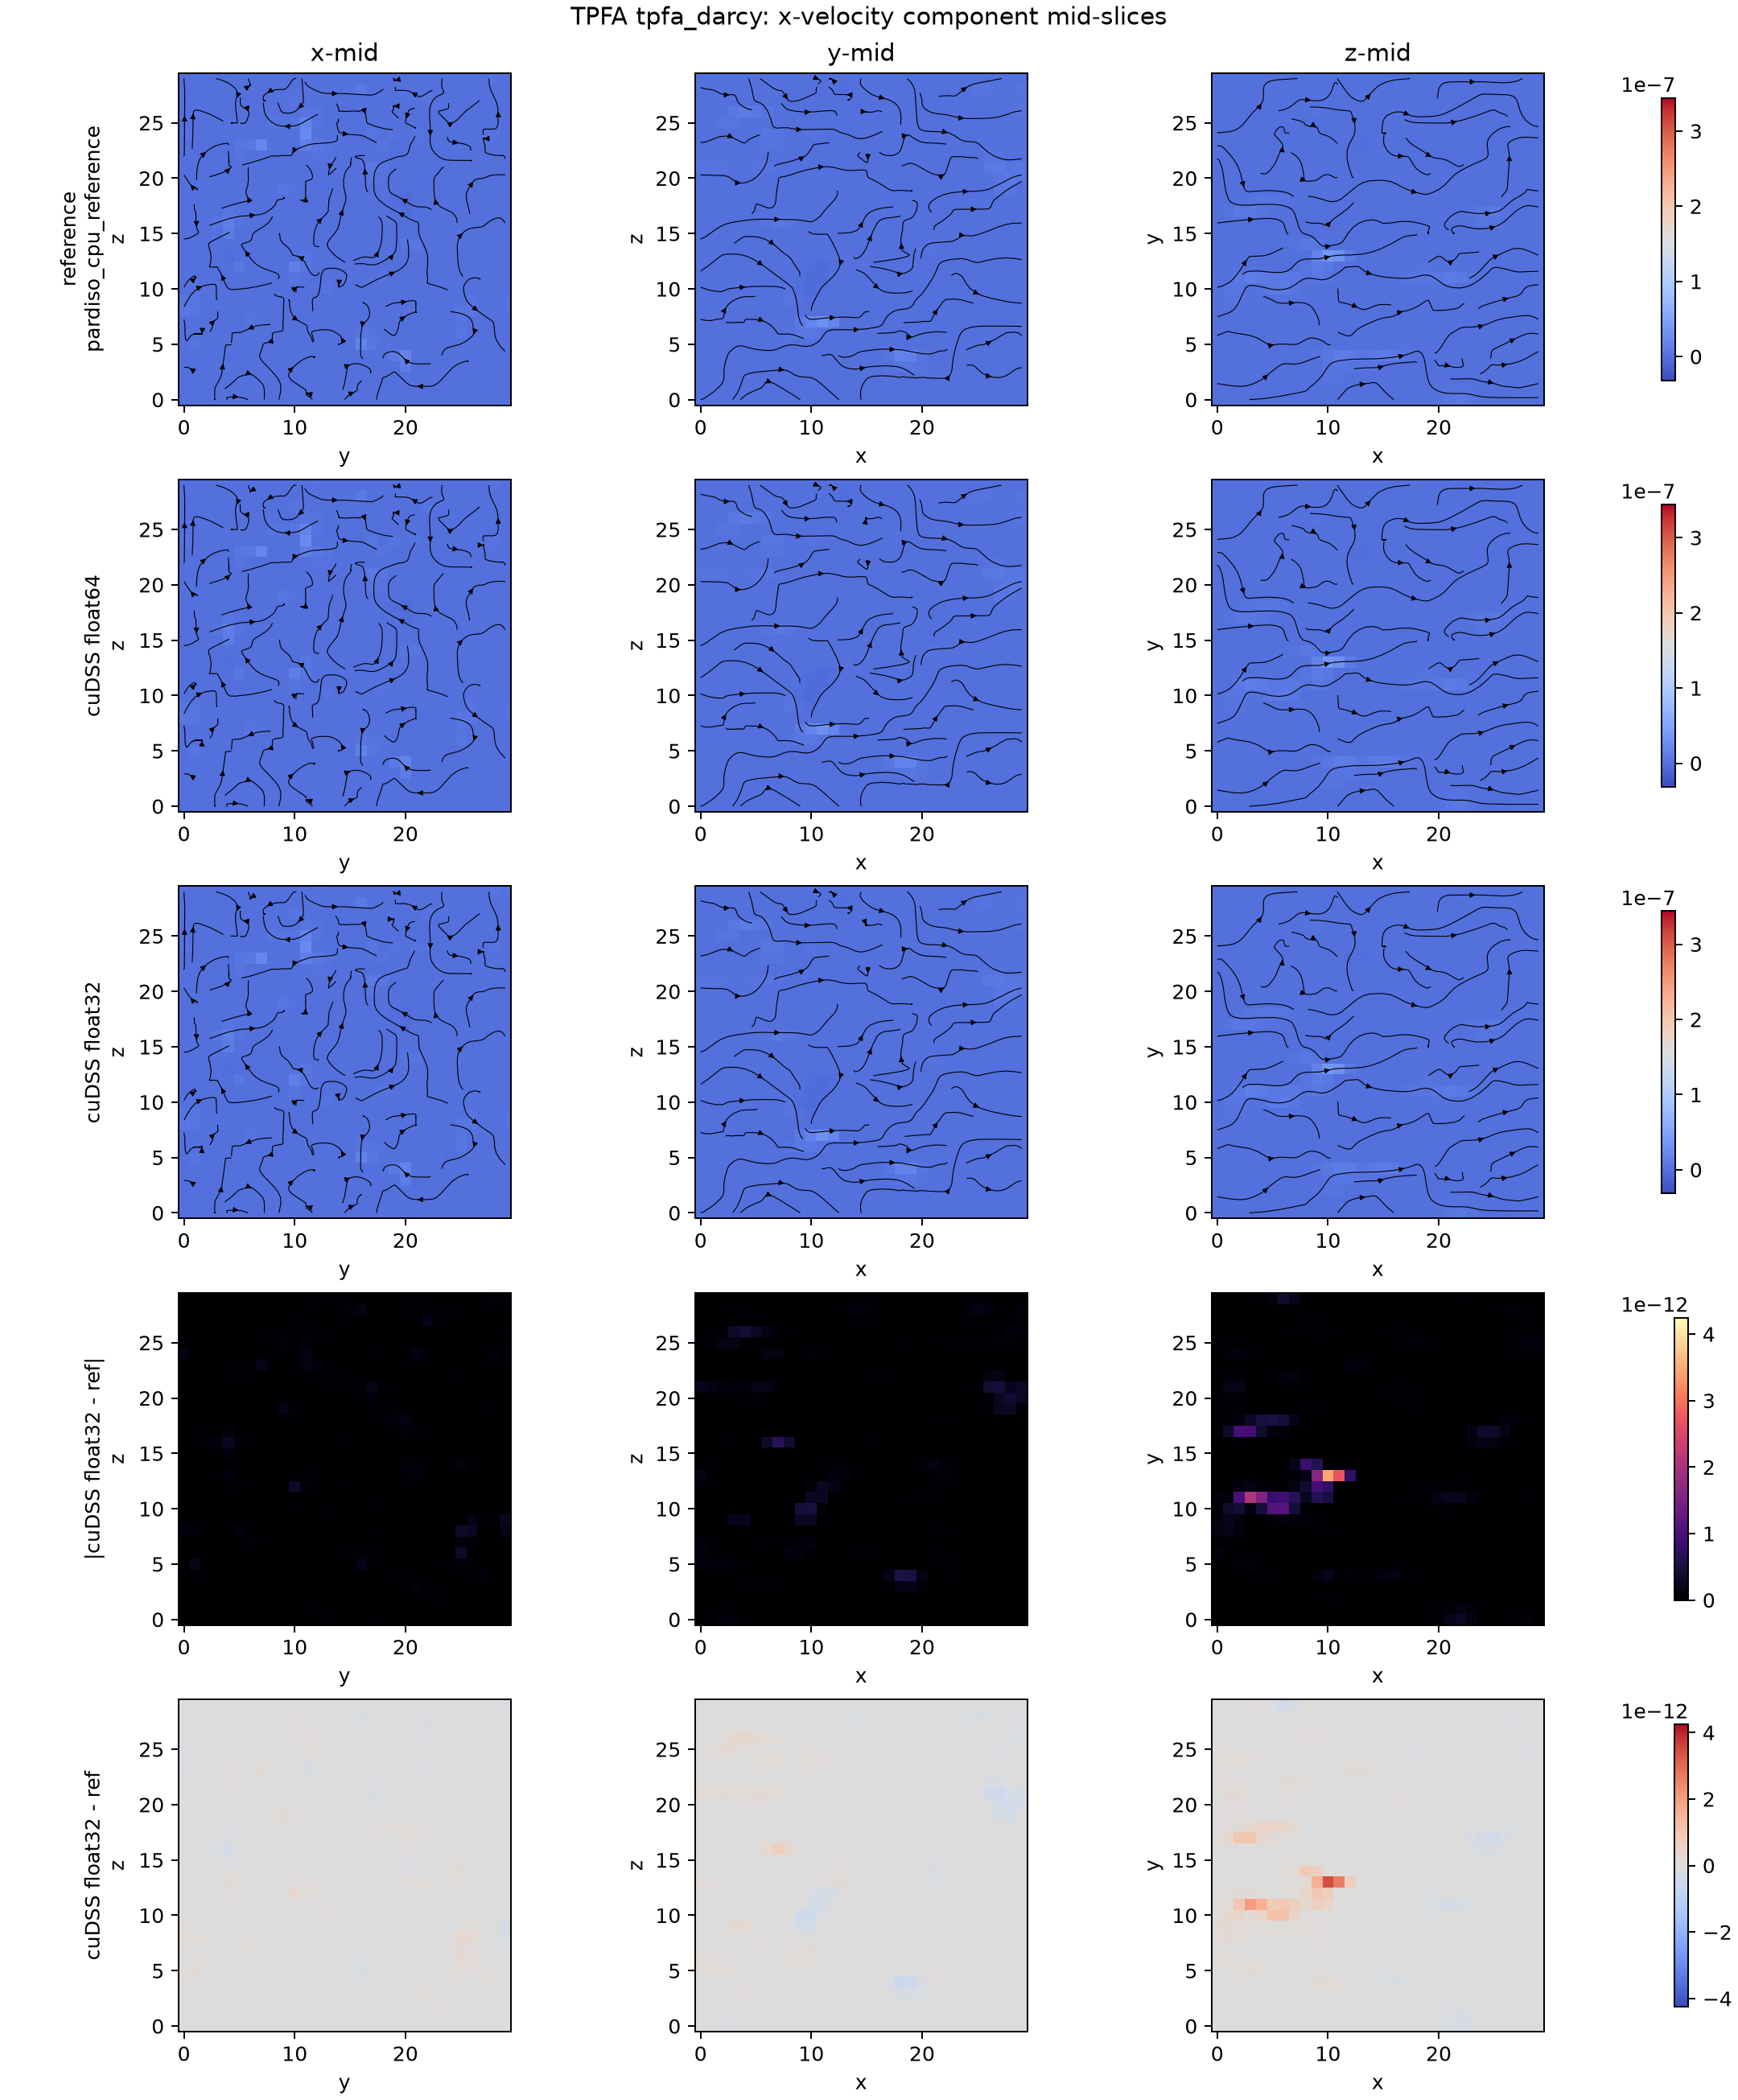

Saved field comparison plot: /prj/thermophase/volpatto/Work/voids/notebooks/outputs/47_mwe_gpu_solver_backend_comparison/gpu_sparse_solver_comparison_image300_phi025_voxel5um_block10_map30_extracted_pnm_cudss_all_gpus_field_plots/TPFA_tpfa_darcy_velocity-x_field_comparison.png


In [12]:
field_plot_dir = output_dir / f"{output_prefix}_field_plots"
field_plot_dir.mkdir(parents=True, exist_ok=True)
field_names = ("pressure", "velocity_x")
field_titles = {
    "pressure": "pressure",
    "velocity_x": f"{flow_axis}-velocity component",
}


def finite_values(values: np.ndarray) -> np.ndarray:
    flat = np.asarray(values, dtype=float).ravel()
    return flat[np.isfinite(flat)]


def robust_limits(arrays: list[np.ndarray]) -> tuple[float, float]:
    finite_parts = [finite_values(array) for array in arrays]
    finite_parts = [part for part in finite_parts if part.size]
    if not finite_parts:
        return 0.0, 1.0
    values = np.concatenate(finite_parts)
    if values.size == 0:
        return 0.0, 1.0
    vmin = float(np.min(values))
    vmax = float(np.max(values))
    if vmin == vmax:
        pad = max(abs(vmin), 1.0) * 1.0e-12
        return vmin - pad, vmax + pad
    return vmin, vmax


def positive_limit(arrays: list[np.ndarray]) -> float:
    finite_parts = [finite_values(array) for array in arrays]
    finite_parts = [part for part in finite_parts if part.size]
    if not finite_parts:
        return 1.0
    vmax = float(np.max(np.concatenate(finite_parts)))
    return vmax if vmax > 0.0 else 1.0e-30


def symmetric_abs_limit(arrays: list[np.ndarray]) -> float:
    finite_parts = [finite_values(array) for array in arrays]
    finite_parts = [part for part in finite_parts if part.size]
    if not finite_parts:
        return 1.0
    vmax = float(np.max(np.abs(np.concatenate(finite_parts))))
    return vmax if vmax > 0.0 else 1.0e-30


def captured_field_arrays(field_name: str) -> list[np.ndarray]:
    return [
        np.asarray(fields[field_name], dtype=float)
        for fields in solution_fields.values()
        if field_name in fields
    ]


def float32_difference_arrays(field_name: str) -> list[np.ndarray]:
    difference_arrays: list[np.ndarray] = []
    for (
        method_family,
        formulation,
    ), reference_label in reference_label_by_formulation.items():
        reference_key = (method_family, formulation, reference_label)
        candidate_key = (method_family, formulation, "nvmath_cudss_float32")
        if reference_key not in solution_fields or candidate_key not in solution_fields:
            continue
        if (
            field_name not in solution_fields[reference_key]
            or field_name not in solution_fields[candidate_key]
        ):
            continue
        reference = np.asarray(solution_fields[reference_key][field_name], dtype=float)
        candidate = np.asarray(solution_fields[candidate_key][field_name], dtype=float)
        difference_arrays.append(candidate - reference)
    return difference_arrays


global_field_limits = {
    field_name: robust_limits(captured_field_arrays(field_name))
    for field_name in field_names
}
global_abs_error_limits = {
    field_name: positive_limit(
        [np.abs(array) for array in float32_difference_arrays(field_name)]
    )
    for field_name in field_names
}
global_signed_diff_limits = {
    field_name: symmetric_abs_limit(float32_difference_arrays(field_name))
    for field_name in field_names
}

field_color_scale_rows = [
    {
        "field": field_name,
        "field_vmin": global_field_limits[field_name][0],
        "field_vmax": global_field_limits[field_name][1],
        "abs_error_vmin": 0.0,
        "abs_error_vmax": global_abs_error_limits[field_name],
        "signed_diff_vmin": -global_signed_diff_limits[field_name],
        "signed_diff_vmax": global_signed_diff_limits[field_name],
    }
    for field_name in field_names
]
field_color_scales = pd.DataFrame(field_color_scale_rows)
field_color_scale_path = output_dir / f"{output_prefix}_field_color_scales.csv"
field_color_scales.to_csv(field_color_scale_path, index=False)
display(field_color_scales)
print(f"Saved field color scales: {field_color_scale_path}")


def relative_l2(candidate: np.ndarray, reference: np.ndarray) -> float:
    mask = np.isfinite(candidate) & np.isfinite(reference)
    if not np.any(mask):
        return np.nan
    numerator = float(np.linalg.norm(candidate[mask] - reference[mask]))
    denominator = float(np.linalg.norm(reference[mask]))
    return numerator / max(denominator, 1.0e-300)


def relative_linf(candidate: np.ndarray, reference: np.ndarray) -> float:
    mask = np.isfinite(candidate) & np.isfinite(reference)
    if not np.any(mask):
        return np.nan
    numerator = float(np.max(np.abs(candidate[mask] - reference[mask])))
    denominator = float(np.max(np.abs(reference[mask])))
    return numerator / max(denominator, 1.0e-300)


def overlay_velocity_streamlines(
    ax,
    fields: dict[str, np.ndarray | str],
    *,
    plane_axis: int,
    in_plane_axes: tuple[str, str],
) -> None:
    velocity = fields.get("velocity_vector")
    if not isinstance(velocity, np.ndarray):
        return
    velocity_values = np.asarray(velocity, dtype=float)
    if velocity_values.ndim != len(field_grid_shape) + 1:
        return
    if velocity_values.shape[0] < len(field_grid_shape):
        return

    u_axis = axis_index(in_plane_axes[0])
    v_axis = axis_index(in_plane_axes[1])
    u = midplane(velocity_values[u_axis], plane_axis).T
    v = midplane(velocity_values[v_axis], plane_axis).T
    finite = np.isfinite(u) & np.isfinite(v)
    if not np.any(finite):
        return
    u = np.where(finite, u, 0.0)
    v = np.where(finite, v, 0.0)
    if not np.any(np.hypot(u, v) > 0.0):
        return

    x_coords = np.arange(u.shape[1], dtype=float)
    y_coords = np.arange(u.shape[0], dtype=float)
    try:
        ax.streamplot(
            x_coords,
            y_coords,
            u,
            v,
            density=0.7,
            color="black",
            linewidth=0.45,
            arrowsize=0.55,
            minlength=0.2,
        )
    except ValueError:
        return


def plot_field_comparison(
    *,
    method_family: str,
    formulation: str,
    reference_label: str,
    field_name: str,
) -> None:
    reference_key = (method_family, formulation, reference_label)
    if reference_key not in solution_fields:
        return
    reference_fields = solution_fields[reference_key]
    if field_name not in reference_fields:
        return
    reference = np.asarray(reference_fields[field_name], dtype=float)

    candidate_rows: list[tuple[str, np.ndarray, str, tuple[str, str, str] | None]] = [
        (f"reference\n{reference_label}", reference, "field", reference_key)
    ]
    for backend_label in ("nvmath_cudss_float64", "nvmath_cudss_float32"):
        key = (method_family, formulation, backend_label)
        if key in solution_fields and field_name in solution_fields[key]:
            candidate_rows.append(
                (
                    backend_label.replace("nvmath_cudss_", "cuDSS "),
                    np.asarray(solution_fields[key][field_name], dtype=float),
                    "field",
                    key,
                )
            )

    float32_key = (method_family, formulation, "nvmath_cudss_float32")
    if float32_key in solution_fields and field_name in solution_fields[float32_key]:
        float32_values = np.asarray(
            solution_fields[float32_key][field_name], dtype=float
        )
        candidate_rows.extend(
            [
                (
                    "|cuDSS float32 - ref|",
                    np.abs(float32_values - reference),
                    "error",
                    None,
                ),
                ("cuDSS float32 - ref", float32_values - reference, "diff", None),
            ]
        )

    if len(candidate_rows) == 1:
        return

    field_vmin, field_vmax = global_field_limits[field_name]
    nrows = len(candidate_rows)
    fig, axes = plt.subplots(
        nrows,
        len(midplane_specs),
        figsize=(4.0 * len(midplane_specs), 2.9 * nrows),
        constrained_layout=True,
        squeeze=False,
    )
    for row_index, (row_label, values, row_kind, source_key) in enumerate(
        candidate_rows
    ):
        if row_kind == "field":
            cmap = "viridis" if field_name == "pressure" else "coolwarm"
            vmin, vmax = field_vmin, field_vmax
        elif row_kind == "error":
            cmap = "magma"
            vmin = 0.0
            vmax = global_abs_error_limits[field_name]
        else:
            cmap = "coolwarm"
            max_abs = global_signed_diff_limits[field_name]
            vmin, vmax = -max_abs, max_abs

        images = []
        for column_index, (plane_label, plane_axis, in_plane_axes) in enumerate(
            midplane_specs
        ):
            ax = axes[row_index, column_index]
            image = midplane(values, plane_axis).T
            im = ax.imshow(image, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
            if (
                field_name == "velocity_x"
                and row_kind == "field"
                and source_key is not None
            ):
                overlay_velocity_streamlines(
                    ax,
                    solution_fields[source_key],
                    plane_axis=plane_axis,
                    in_plane_axes=in_plane_axes,
                )
            images.append(im)
            if row_index == 0:
                ax.set_title(plane_label)
            if column_index == 0:
                ax.set_ylabel(row_label)
            ax.set_xlabel(in_plane_axes[0])
            ax.set_ylabel(
                f"{row_label}\n{in_plane_axes[1]}"
                if column_index == 0
                else in_plane_axes[1]
            )
        fig.colorbar(images[-1], ax=axes[row_index, :].tolist(), shrink=0.85)

    fig.suptitle(
        f"{method_family} {formulation}: {field_titles[field_name]} mid-slices"
    )
    safe_field = field_name.replace("_", "-")
    figure_path = (
        field_plot_dir
        / f"{method_family}_{formulation}_{safe_field}_field_comparison.png"
    )
    save_and_display_figure(fig, figure_path)
    print(f"Saved field comparison plot: {figure_path}")


field_error_rows: list[dict[str, object]] = []
for (
    method_family,
    formulation,
), reference_label in reference_label_by_formulation.items():
    reference_key = (method_family, formulation, reference_label)
    if reference_key not in solution_fields:
        continue
    for backend_label in ("nvmath_cudss_float64", "nvmath_cudss_float32"):
        candidate_key = (method_family, formulation, backend_label)
        if candidate_key not in solution_fields:
            continue
        for field_name in field_names:
            if (
                field_name not in solution_fields[reference_key]
                or field_name not in solution_fields[candidate_key]
            ):
                continue
            reference = np.asarray(
                solution_fields[reference_key][field_name], dtype=float
            )
            candidate = np.asarray(
                solution_fields[candidate_key][field_name], dtype=float
            )
            field_error_rows.append(
                {
                    "method_family": method_family,
                    "formulation": formulation,
                    "backend_label": backend_label,
                    "field": field_name,
                    "reference_backend": reference_label,
                    "relative_l2": relative_l2(candidate, reference),
                    "relative_linf": relative_linf(candidate, reference),
                    "absolute_linf": float(np.nanmax(np.abs(candidate - reference))),
                }
            )

field_errors = pd.DataFrame(field_error_rows)
field_error_path = output_dir / f"{output_prefix}_field_error_metrics.csv"
field_errors.to_csv(field_error_path, index=False)
display(field_errors)
print(f"Saved field error metrics: {field_error_path}")

if field_errors.empty:
    print("No solution fields were captured for visual comparison.")
else:
    plot_errors = field_errors.copy()
    plot_errors["label"] = (
        plot_errors["method_family"].astype(str)
        + "\n"
        + plot_errors["formulation"].astype(str)
        + "\n"
        + plot_errors["backend_label"].astype(str)
        + "\n"
        + plot_errors["field"].astype(str)
    )
    x = np.arange(len(plot_errors), dtype=float)
    fig, ax = plt.subplots(figsize=(14.0, 5.8), constrained_layout=True)
    ax.bar(
        x,
        np.maximum(plot_errors["relative_l2"], 1.0e-18),
        color="tab:purple",
        alpha=0.75,
    )
    ax.set_yscale("log")
    ax.set_ylabel("relative L2 field error")
    ax.set_title("Solution-field errors vs selected CPU reference")
    ax.set_xticks(x)
    ax.set_xticklabels(plot_errors["label"], rotation=70, ha="right")
    ax.grid(axis="y", which="both", alpha=0.25)
    field_error_plot_path = output_dir / f"{output_prefix}_field_relative_l2_error.png"
    save_and_display_figure(fig, field_error_plot_path)
    print(f"Saved field error plot: {field_error_plot_path}")

    for (
        method_family,
        formulation,
    ), reference_label in reference_label_by_formulation.items():
        for field_name in field_names:
            plot_field_comparison(
                method_family=method_family,
                formulation=formulation,
                reference_label=reference_label,
                field_name=field_name,
            )